In [ ]:
# ==========================================================
# Install Required Packages (Run Only Once)
# ==========================================================

!pip -q install torchdiffeq

In [ ]:
# --------------------------------------------------
# BLOCK 1 : Imports
# --------------------------------------------------

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchdiffeq import odeint

warnings.filterwarnings("ignore")

# --------------------------------------------------
# Device Configuration
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device :", device)

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device : cpu


In [ ]:
# --------------------------------------------------
# BLOCK 2 : Influenza Model Parameters
# --------------------------------------------------

params = {
    "Lambda": 0.06,
    "mu": 1/(80*365),
    "alpha": 0.20,
    "nu": 0.00057,
    "delta": 0.001,
    "beta0": 1.5378,
    "amp": 0.40,
    "omega": 0.0038,
    "C": 0.010,
    "d": 13.9394
}

print("Mechanistic Parameters")
for key, value in params.items():
    print(f"{key:10s} : {value}")

Mechanistic Parameters
Lambda     : 0.06
mu         : 3.424657534246575e-05
alpha      : 0.2
nu         : 0.00057
delta      : 0.001
beta0      : 1.5378
amp        : 0.4
omega      : 0.0038
C          : 0.01
d          : 13.9394


In [ ]:
# --------------------------------------------------
# BLOCK 3 : Seasonal Residual Neural Network
# --------------------------------------------------

class SeasonalResidualNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Xavier Initialization
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, X, t):
        # Annual seasonal cycle
        sin1 = torch.sin(2*math.pi*t/52)
        cos1 = torch.cos(2*math.pi*t/52)

        # Semi-annual seasonal cycle
        sin2 = torch.sin(4*math.pi*t/52)
        cos2 = torch.cos(4*math.pi*t/52)

        features = torch.cat([X, t, sin1, cos1, sin2, cos2], dim=1)

        residual = self.network(features)

        # Limit residual magnitude
        residual = 0.8*torch.tanh(residual)

        return residual

In [ ]:
# --------------------------------------------------
# BLOCK 4 : UDE ODE Function
# --------------------------------------------------

def influenza_rhs_ude(t, X, model, params):
    S = X[:, 0:1]
    I = X[:, 1:2]
    R = X[:, 2:3]

    Lambda = params["Lambda"]
    mu     = params["mu"]
    alpha  = params["alpha"]
    nu     = params["nu"]
    delta  = params["delta"]
    omega  = params["omega"]
    C      = params["C"]
    d      = params["d"]

    beta = params["beta0"] * (1 + params["amp"] * torch.cos(2 * math.pi * t / 52))

    t_input = torch.ones_like(S) * t
    residual = model(X, t_input)
    beta = beta + residual
    beta = torch.clamp(beta, min=0.02, max=5.0)

    N = S + I + R + 1e-8

    dS = Lambda - beta*S*I/N - (mu+nu)*S + omega*R
    dI = beta*S*I/N - (mu+alpha+delta)*I - (C*I)/(1+d*I)
    dR = alpha*I - (mu+omega)*R + nu*S + (C*I)/(1+d*I)

    return torch.cat([dS, dI, dR], dim=1)


# --------------------------------------------------
# ODE Wrapper
# --------------------------------------------------

class ODEFunc(nn.Module):
    def __init__(self, model, params):
        super().__init__()
        self.model = model
        self.params = params

    def forward(self, t, X):
        return influenza_rhs_ude(t, X, self.model, self.params)

In [ ]:
# --------------------------------------------------
# BLOCK 5 : Optimizer + Scheduler
# --------------------------------------------------

seasonal_residual_nn = SeasonalResidualNN().to(device)

ode_func = ODEFunc(seasonal_residual_nn, params).to(device)

loss_fn = nn.MSELoss()

optimizer = optim.AdamW(
    seasonal_residual_nn.parameters(),
    lr=2e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=100
)

print("Optimizer and Scheduler initialized.")

Optimizer and Scheduler initialized.


In [ ]:
# --------------------------------------------------
# BLOCK 6 : Data Preparation
# --------------------------------------------------

data = pd.read_csv("/content/California.csv")
print(data.head())
print(data.columns)

t_data = np.arange(len(data), dtype=np.float32)

I_obs = data["Total_ILI"].values.astype(np.float32)
I_obs = I_obs / np.max(I_obs)

I_obs_tensor = torch.tensor(I_obs, dtype=torch.float32, device=device)

# --------------------------------------------------
# Initial Conditions — anchored to the true first data point
# --------------------------------------------------

I0 = I_obs_tensor[0].item()
R0 = 0.0
S0 = 1.0 - I0 - R0

if S0 < 0:
    print("Warning: Calculated S0 is negative, adjusting to ensure S0 >= 0.")
    S0 = 0.0
    R0 = 1.0 - I0

X0 = torch.tensor([[S0, I0, R0]], dtype=torch.float32, device=device)

t_tensor = torch.tensor(t_data, dtype=torch.float32, device=device)

print("Number of observations:", len(t_data))
print("Initial condition:", X0)

      season  date_code  weekending      region  Total_ILI  \
0  2016-2017     201701  01-07-2017  California       2686   
1  2016-2017     201702   1/14/2017  California       2398   
2  2016-2017     201703   1/21/2017  California       2277   
3  2016-2017     201704   1/28/2017  California       2503   
4  2016-2017     201705  02-04-2017  California       2450   

   Total_Patients_Seen  Percent_ILI  Number_Providers_Reporting  
0                70547         3.81                         162  
1                71259         3.37                         156  
2                72819         3.13                         156  
3                75796         3.30                         156  
4                74251         3.30                         148  
Index(['season', 'date_code', 'weekending', 'region', 'Total_ILI',
       'Total_Patients_Seen', 'Percent_ILI', 'Number_Providers_Reporting'],
      dtype='object')
Number of observations: 195
Initial condition: tensor([[0.5362, 0.

In [ ]:
# --------------------------------------------------
# BLOCK 6.5 : Mechanistic Parameter Calibration (FIXED)
# --------------------------------------------------

print("Starting Mechanistic Calibration ...")

# --------------------------------------------------
# Learnable Parameters  (ONLY beta0 and I0 — C, d stay FIXED, same as original)
# --------------------------------------------------

beta0 = nn.Parameter(
    torch.tensor(params["beta0"], dtype=torch.float32, device=device)
)

# Bound I0 around the TRUE observed first value instead of a hard 0.05 cap
I0_true = I_obs[0]
I0_lo, I0_hi = max(0.001, I0_true * 0.5), min(0.99, I0_true * 1.5)

def inv_sigmoid_scaled(val, lo, hi):
    frac = (val - lo) / (hi - lo)
    frac = min(max(frac, 1e-4), 1 - 1e-4)
    return math.log(frac / (1 - frac))

I0_param = nn.Parameter(
    torch.tensor([[inv_sigmoid_scaled(I0_true, I0_lo, I0_hi)]], dtype=torch.float32, device=device)
)

# --------------------------------------------------
# Mechanistic ODE  (C and d fixed, exactly like the original working version)
# --------------------------------------------------

class MechanisticODECalibration(nn.Module):
    def __init__(self, params):
        super().__init__()
        self.params = params

    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = F.softplus(beta0)
        beta = beta * (1 + self.params["amp"] * torch.cos(2*math.pi*t/52))
        beta = torch.clamp(beta, 0.02, 5.0)

        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR], dim=1)

calibration_model = MechanisticODECalibration(params).to(device)

# --------------------------------------------------
# Optimizer  (only beta0, I0_param — same as original)
# --------------------------------------------------

optimizer_calib = optim.AdamW([beta0, I0_param], lr=3e-3, weight_decay=1e-6)
scheduler_calib = optim.lr_scheduler.ReduceLROnPlateau(optimizer_calib, mode="min", factor=0.5, patience=30)

best_loss = float("inf")
best_beta = None
best_I0 = None

# --------------------------------------------------
# Training
# --------------------------------------------------

for epoch in range(250):
    optimizer_calib.zero_grad()

    I0 = torch.sigmoid(I0_param) * (I0_hi - I0_lo) + I0_lo   # <-- fixed: bounded near true I0, not capped at 0.05
    R0 = torch.zeros_like(I0)
    S0 = 1.0 - I0 - R0                                        # <-- fixed: derived from I0, not hardcoded 0.99
    X0_fit = torch.cat([S0, I0, R0], dim=1)

    pred = odeint(calibration_model, X0_fit, t_tensor, method="rk4")
    if pred.dim() == 3: pred = pred.squeeze(1)

    loss = F.mse_loss(pred[:,1], I_obs_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_([beta0, I0_param], 1.0)
    optimizer_calib.step()
    scheduler_calib.step(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_beta = F.softplus(beta0).detach().clone()
        best_I0 = I0.detach().clone()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss={loss.item():.6f} | beta0={F.softplus(beta0).item():.4f} | I0={I0.item():.4f}")

# --------------------------------------------------
# Update Global Parameters
# --------------------------------------------------

params["beta0"] = best_beta.item()
I0_val = best_I0.item()
S0_val = 1.0 - I0_val
X0 = torch.tensor([[S0_val, I0_val, 0.0]], dtype=torch.float32, device=device)

print("\nCalibration Finished")
print(f"Best Loss : {best_loss:.6f}")
print(f"Estimated beta0 : {params['beta0']:.4f}")
print(f"Estimated I0 : {I0_val:.5f}  (true observed I0 = {I_obs[0]:.5f})")
print(f"Final X0 : {X0}")

Starting Mechanistic Calibration ...
Epoch   0 | Loss=0.046437 | beta0=1.7300 | I0=0.4638
Epoch  50 | Loss=0.045865 | beta0=1.6037 | I0=0.4800
Epoch 100 | Loss=0.044926 | beta0=1.4627 | I0=0.4900
Epoch 150 | Loss=0.043361 | beta0=1.3076 | I0=0.4898
Epoch 200 | Loss=0.041194 | beta0=1.1524 | I0=0.4787

Calibration Finished
Best Loss : 0.038089
Estimated beta0 : 1.0004
Estimated I0 : 0.46073  (true observed I0 = 0.46382)
Final X0 : tensor([[0.5393, 0.4607, 0.0000]])


In [ ]:
# --------------------------------------------------
# BLOCK 7 : UDE Training (Self-Contained)
# --------------------------------------------------

class SeasonalResidualNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8,128), nn.Tanh(),
            nn.Linear(128,128), nn.Tanh(),
            nn.Linear(128,64), nn.Tanh(),
            nn.Linear(64,1)
        )
    def forward(self,X,t):
        sin1, cos1 = torch.sin(2*math.pi*t/52), torch.cos(2*math.pi*t/52)
        sin2, cos2 = torch.sin(4*math.pi*t/52), torch.cos(4*math.pi*t/52)
        features = torch.cat([X, t, sin1, cos1, sin2, cos2], dim=1)
        return 1.0 * torch.tanh(self.network(features))

class ODEFunc(nn.Module):
    def __init__(self, model, params):
        super().__init__()
        self.model = model
        self.params = params
    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        t_input = torch.ones_like(S) * t
        beta = torch.clamp(beta + self.model(X, t_input), 0.02, 5.0)
        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR],dim=1)

seasonal_residual_nn = SeasonalResidualNN().to(device)
ode_func = ODEFunc(seasonal_residual_nn, params).to(device)
optimizer = optim.AdamW(seasonal_residual_nn.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=50)
loss_fn = nn.MSELoss()

print("Starting UDE Training...")
num_epochs, best_loss, patience, counter = 500, float("inf"), 100, 0
loss_history = []                      # <-- must be defined right here, right before the loop

for epoch in range(num_epochs):
    optimizer.zero_grad()
    pred_X = odeint(ode_func, X0, t_tensor, method="rk4")
    if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

    loss_data = loss_fn(pred_X[:,1], I_obs_tensor)
    smooth_loss = torch.mean((pred_X[1:,1] - pred_X[:-1,1])**2)
    loss = loss_data + 5e-4 * smooth_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(seasonal_residual_nn.parameters(), 1.0)
    optimizer.step()
    scheduler.step(loss.item())

    loss_history.append(loss.item())   # <-- must run every epoch

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
        torch.save(seasonal_residual_nn.state_dict(), "best_ude_model.pt")
    else:
        counter += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.6f} | Best: {best_loss:.6f}")

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

seasonal_residual_nn.load_state_dict(torch.load("best_ude_model.pt"))
print(f"\nTraining Finished. Best Loss: {best_loss:.6f} | Epochs recorded: {len(loss_history)}")

Starting UDE Training...
Epoch   0 | Loss: 0.036303 | Best: 0.036303
Epoch  50 | Loss: 0.021321 | Best: 0.021106
Epoch 100 | Loss: 0.018593 | Best: 0.018593
Epoch 150 | Loss: 0.018265 | Best: 0.018171
Epoch 200 | Loss: 0.018565 | Best: 0.017786
Epoch 250 | Loss: 0.017338 | Best: 0.017338
Epoch 300 | Loss: 0.015858 | Best: 0.015858
Epoch 350 | Loss: 0.007011 | Best: 0.007011
Epoch 400 | Loss: 0.004388 | Best: 0.004388
Epoch 450 | Loss: 0.003829 | Best: 0.003829

Training Finished. Best Loss: 0.003331 | Epochs recorded: 500


In [ ]:
# --------------------------------------------------
# BLOCK 8 : Prediction
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    pred_X = odeint(ode_func, X0, t_tensor, method="dopri5")
    if pred_X.dim() == 3:
        pred_X = pred_X.squeeze(1)
    I_ude = pred_X[:, 1].cpu().numpy()
    I_ude_final = I_ude  # used by Block 11 metrics table

In [ ]:
# --------------------------------------------------
# BLOCK 9 : Performance Metrics
# --------------------------------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(I_obs, I_ude))
mae = mean_absolute_error(I_obs, I_ude)
mape = np.mean(np.abs((I_obs - I_ude) / (I_obs + 1e-8))) * 100
smape = np.mean(2*np.abs(I_obs - I_ude) / (np.abs(I_obs) + np.abs(I_ude) + 1e-8)) * 100

print()
print("="*40)
print("Performance of Proposed UDE")
print("="*40)
print(f"RMSE  : {rmse:.6f}")
print(f"MAE   : {mae:.6f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")


Performance of Proposed UDE
RMSE  : 0.057779
MAE   : 0.042748
MAPE  : 24.20%
sMAPE : 22.60%


In [ ]:
# --------------------------------------------------
# BLOCK 9.5 : Prepare Fine-Grid & Actual-Scale Data for Visualization
# --------------------------------------------------

# --------------------------------------------------
# Define the mechanistic-only ODE (moved up from Block 10,
# needed here before Block 10 now runs)
# --------------------------------------------------

class MechanisticODEFunc(nn.Module):
    def __init__(self, params):
        super().__init__()
        self.params = params

    def forward(self, t, X):
        S = X[:,0:1]
        I = X[:,1:2]
        R = X[:,2:3]

        Lambda = self.params["Lambda"]
        mu     = self.params["mu"]
        alpha  = self.params["alpha"]
        nu     = self.params["nu"]
        delta  = self.params["delta"]
        omega  = self.params["omega"]
        C      = self.params["C"]
        d      = self.params["d"]

        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        beta = torch.clamp(beta, min=0.02, max=5.0)

        N = S + I + R + 1e-8

        dS = Lambda - beta*S*I/N - (mu+nu)*S + omega*R
        dI = beta*S*I/N - (mu+alpha+delta)*I - (C*I)/(1+d*I)
        dR = alpha*I - (mu+omega)*R + nu*S + (C*I)/(1+d*I)

        return torch.cat([dS,dI,dR],dim=1)

mech_ode_func = MechanisticODEFunc(params).to(device)

with torch.no_grad():
    pred_X_mech = odeint(mech_ode_func, X0, t_tensor, method="dopri5")
    if pred_X_mech.dim() == 3:
        pred_X_mech = pred_X_mech.squeeze(1)
    I_mech = pred_X_mech[:, 1].cpu().numpy()

# --------------------------------------------------
# Original (un-normalized) scale — I_obs was normalized to [0,1]
# --------------------------------------------------

I_max = np.max(data["Total_ILI"].values.astype(np.float32))

observed_actual = I_obs * I_max          # observed data, actual ILI scale

# --------------------------------------------------
# Fine time grid for smooth curves
# --------------------------------------------------

t_fine = np.linspace(t_data[0], t_data[-1], 2000).astype(np.float32)
t_fine_tensor = torch.tensor(t_fine, dtype=torch.float32, device=device)

seasonal_residual_nn.eval()

with torch.no_grad():
    # Mechanistic model on fine grid
    mech_prediction = odeint(mech_ode_func, X0, t_fine_tensor, method="dopri5")
    if mech_prediction.dim() == 3:
        mech_prediction = mech_prediction.squeeze(1)
    I_mech_fine = mech_prediction[:, 1].cpu().numpy()

    # UDE on fine grid (keep full state — needed for the residual plot)
    ude_prediction = odeint(ode_func, X0, t_fine_tensor, method="dopri5")
    if ude_prediction.dim() == 2:
        ude_prediction = ude_prediction.unsqueeze(1)   # -> [T,1,3]
    I_ude_fine = ude_prediction[:, 0, 1].cpu().numpy()

I_mech_actual = I_mech_fine * I_max
I_ude_actual  = I_ude_fine  * I_max

# --------------------------------------------------
# Predictions AT the observed time points (for the error plot)
# --------------------------------------------------

I_mech_obs_actual = I_mech * I_max   # from the dopri5 run just above
I_ude_obs_actual  = I_ude  * I_max   # I_ude already computed in Block 8

print("Fine-grid predictions and actual-scale data ready.")
print(f"I_max (denormalization factor): {I_max:.2f}")

Fine-grid predictions and actual-scale data ready.
I_max (denormalization factor): 5791.00


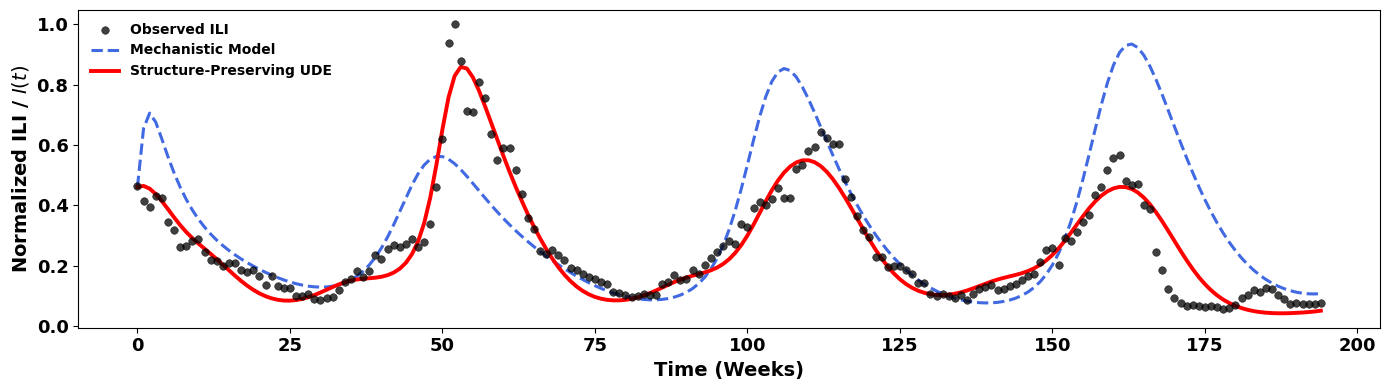

In [ ]:
# --------------------------------------------------
# BLOCK 10 : Visualization
# --------------------------------------------------
# mech_ode_func and I_mech already computed in Block 9.5 — reused here.

plt.figure(figsize=(14,4))

plt.scatter(t_data, I_obs, color="black", s=30, alpha=0.75,
            edgecolors="black", linewidth=0.4, label="Observed ILI", zorder=3)

plt.plot(t_data, I_mech, "--", linewidth=2.2, color="royalblue", label="Mechanistic Model")

plt.plot(t_data, I_ude, "-", linewidth=2.8, color="red", label="Structure-Preserving UDE")

plt.xlabel("Time (Weeks)", fontsize=14, fontweight="bold")
plt.ylabel(r"Normalized ILI / $I(t)$",
           fontsize=14, fontweight="bold")
plt.xticks(fontsize=13,fontweight="bold")
plt.yticks(fontsize=13,fontweight="bold")
#plt.grid(linestyle="--", alpha=0.35)
plt.legend(frameon=False, fontsize=12, loc="upper left", prop={"weight": "bold"})

plt.tight_layout()
plt.savefig("Mechanistic_to_UDE_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    return rmse, mae, mape, smape

rmse_mech, mae_mech, mape_mech, smape_mech = compute_metrics(I_obs, I_mech)
rmse_ude_fin, mae_ude_fin, mape_ude_fin, smape_ude_fin = compute_metrics(I_obs, I_ude_final)

refined_results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "MAPE", "sMAPE"],
    "Original Mechanistic": [rmse_mech, mae_mech, mape_mech, smape_mech],
    "Refined UDE (Weighted)": [rmse_ude_fin, mae_ude_fin, mape_ude_fin, smape_ude_fin],
    "Final Improvement (%)": [
        100*(rmse_mech - rmse_ude_fin)/rmse_mech,
        100*(mae_mech - mae_ude_fin)/mae_mech,
        100*(mape_mech - mape_ude_fin)/mape_mech,
        100*(smape_mech - smape_ude_fin)/smape_mech
    ]
})

print("=== UPDATED PERFORMANCE COMPARISON (REFINED MODEL) ===")
print(refined_results.round(4).to_string(index=False))

=== UPDATED PERFORMANCE COMPARISON (REFINED MODEL) ===
Metric  Original Mechanistic  Refined UDE (Weighted)  Final Improvement (%)
  RMSE                0.1949                  0.0578                70.3601
   MAE                0.1268                  0.0427                66.2747
  MAPE               66.4973                 24.1989                63.6092
 sMAPE               37.2223                 22.5963                39.2938


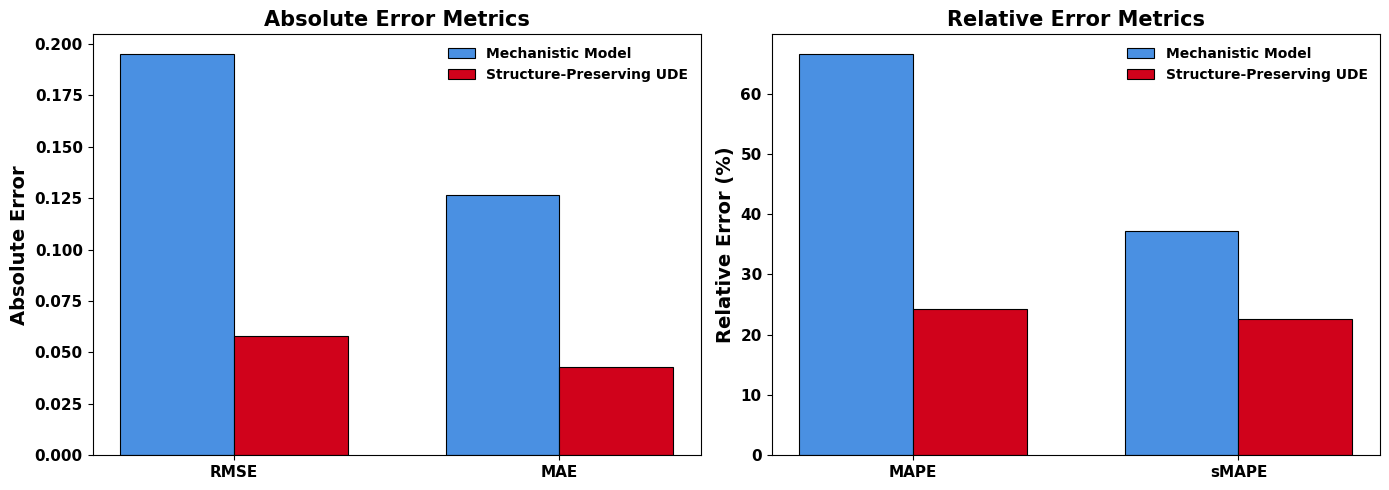

In [ ]:
# --------------------------------------------------
# BLOCK 9B : Publication Two-Panel Comparison
# --------------------------------------------------

metrics = refined_results["Metric"].values
mech = refined_results["Original Mechanistic"].values
ude = refined_results["Refined UDE (Weighted)"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35
x1 = np.arange(2)
x2 = np.arange(2)

ax1.bar(x1 - width/2, mech[0:2], width, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax1.bar(x1 + width/2, ude[0:2], width, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Absolute Error', fontsize=14, fontweight='bold')
ax1.set_xticks(x1)
ax1.set_xticklabels(['RMSE', 'MAE'], fontsize=13, fontweight='bold')
ax1.set_title('Absolute Error Metrics', loc='center', fontsize=15, fontweight='bold')
ax1.legend(frameon=False, fontsize=12, prop={"weight": "bold"})

ax2.bar(x2 - width/2, mech[2:4], width, label='Mechanistic Model', color='#4A90E2', edgecolor='black', linewidth=0.8)
ax2.bar(x2 + width/2, ude[2:4], width, label='Structure-Preserving UDE', color='#D0021B', edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Relative Error (%)', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(['MAPE', 'sMAPE'], fontsize=13, fontweight='bold')
ax2.set_title('Relative Error Metrics', loc='center', fontsize=15, fontweight='bold')
ax2.legend(frameon=False, fontsize=12, prop={"weight": "bold"})
#plt.legend(frameon=False, fontsize=12, loc="upper left", prop={"weight": "bold"})

# --- Bold tick labels on both axes (y-ticks weren't bolded before) ---
plt.setp(ax1.get_xticklabels(), fontweight="bold", fontsize=11)
plt.setp(ax1.get_yticklabels(), fontweight="bold", fontsize=11)
plt.setp(ax2.get_xticklabels(), fontweight="bold", fontsize=11)
plt.setp(ax2.get_yticklabels(), fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("Publication_Two_Panel_Comparison.png", dpi=600, bbox_inches='tight')
plt.show()

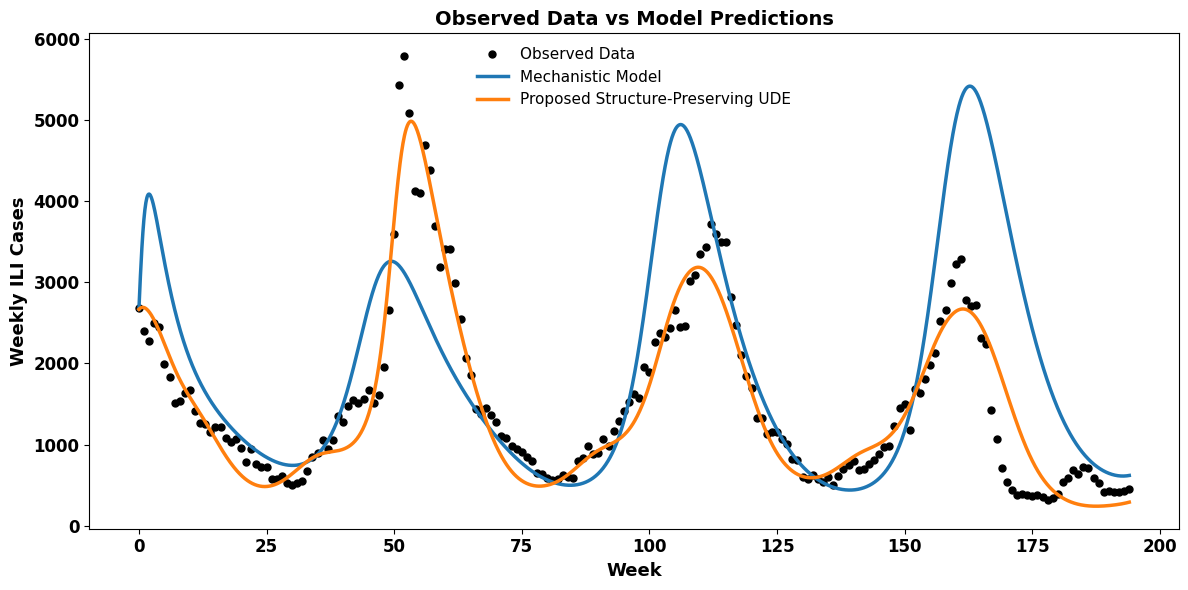

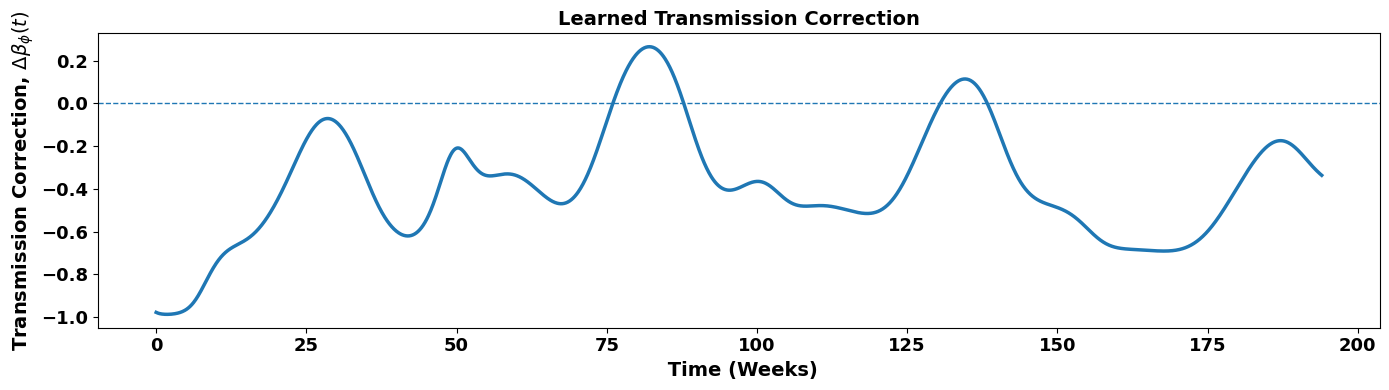

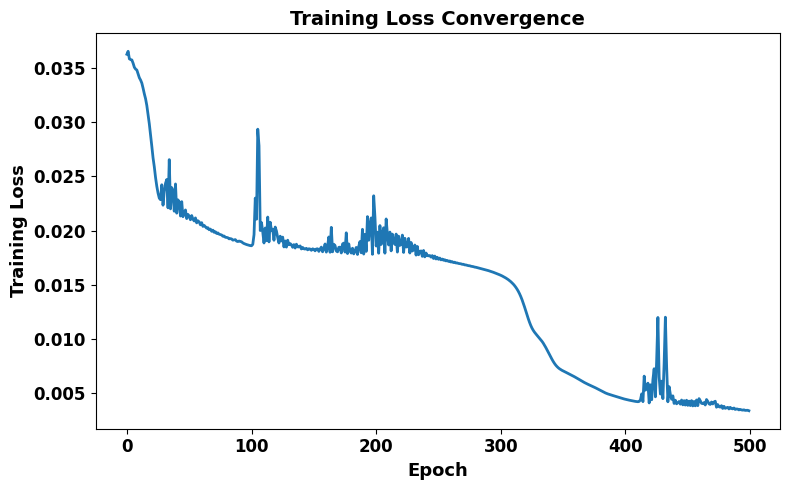

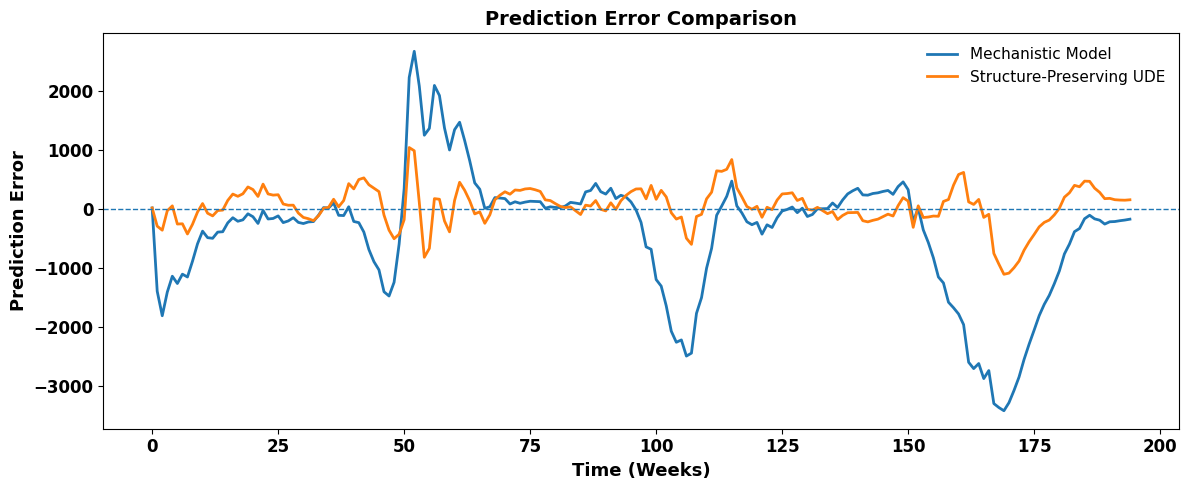

Workflow Completed Successfully
✓ Mechanistic Model Calibrated
✓ Structure-Preserving UDE Trained
✓ Predictions Generated
✓ Performance Evaluated
✓ Figures Created


In [ ]:
# ==========================================================
# Block 12 : Additional Visualizations
# ==========================================================

import matplotlib.pyplot as plt

plt.style.use("default")

# ----------------------------------------------------------
# Figure 1 : Observed vs Model Predictions
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(t_data, observed_actual, "ko", markersize=5, label="Observed Data")
plt.plot(t_fine, I_mech_actual, linewidth=2.5, label="Mechanistic Model")
plt.plot(t_fine, I_ude_actual, linewidth=2.5, label="Proposed Structure-Preserving UDE")

plt.xlabel("Week", fontsize=13,fontweight="bold")
plt.ylabel("Weekly ILI Cases", fontsize=13,fontweight="bold")
plt.title("Observed Data vs Model Predictions", fontsize=14, fontweight="bold")
plt.legend(fontsize=11,frameon=False)
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 2 : Residual Correction
# ----------------------------------------------------------

with torch.no_grad():
    residual = seasonal_residual_nn(
        ude_prediction[:,0,:],
        t_fine_tensor.unsqueeze(1)
    )

residual = residual.cpu().numpy().flatten()

plt.figure(figsize=(14,4))
plt.plot(t_fine, residual, linewidth=2.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(" Time (Weeks)", fontsize=14,fontweight="bold")
plt.ylabel(
    r"Transmission Correction, $\Delta \beta_\phi(t)$",
    fontsize=14,
    fontweight="bold"
)
plt.title("Learned Transmission Correction", fontsize=14, fontweight="bold")
#plt.grid(alpha=0.3)
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 3 : Training Loss
# ----------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch", fontsize=13,fontweight="bold")
plt.ylabel("Training Loss", fontsize=13,fontweight="bold")
plt.title("Training Loss Convergence", fontsize=14, fontweight="bold")
#plt.grid(alpha=0.3)
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 4 : Prediction Errors
# ----------------------------------------------------------

error_mech = observed_actual - I_mech_obs_actual
error_ude = observed_actual - I_ude_obs_actual

plt.figure(figsize=(12,5))
plt.plot(t_data, error_mech, linewidth=2, label="Mechanistic Model")
plt.plot(t_data, error_ude, linewidth=2, label="Structure-Preserving UDE")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time (Weeks)", fontsize=13,fontweight="bold")
plt.ylabel("Prediction Error", fontsize=13,fontweight="bold")
plt.title("Prediction Error Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, frameon=False)
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*70)
print("Workflow Completed Successfully")
print("="*70)
print("✓ Mechanistic Model Calibrated")
print("✓ Structure-Preserving UDE Trained")
print("✓ Predictions Generated")
print("✓ Performance Evaluated")
print("✓ Figures Created")
print("="*70)

Block 13: Learned Transmission Rate — Baseline vs Effective β(t)

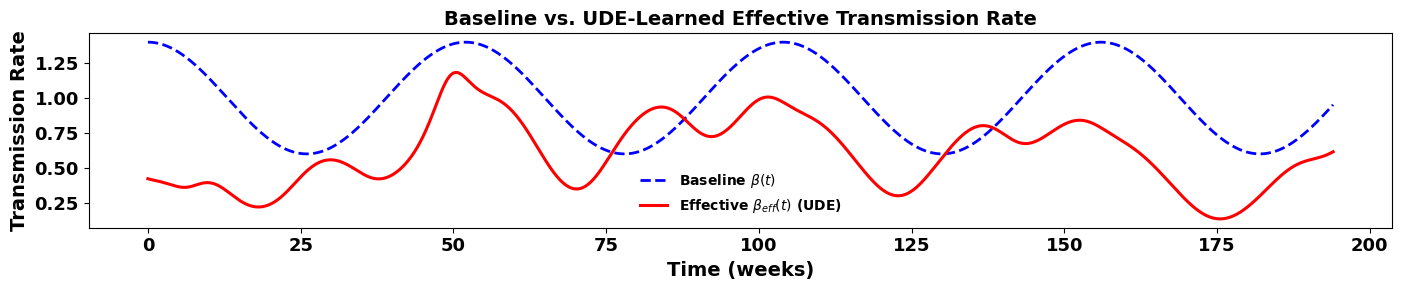

Mean residual correction to beta: -0.3811


In [ ]:
# --------------------------------------------------
# BLOCK 13 : Learned Transmission Rate (Baseline vs Effective)
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    beta_base_fine = params["beta0"] * (1.0 + params["amp"] * np.cos(2 * np.pi * t_fine / 52))

    # Effective beta computed using the ACTUAL trajectory state at each time point
    # (more accurate than evaluating at a single fixed state)
    S_traj = ude_prediction[:, 0, 0].cpu().numpy()
    I_traj = ude_prediction[:, 0, 1].cpu().numpy()
    R_traj = ude_prediction[:, 0, 2].cpu().numpy()

    beta_eff_fine = []
    for i in range(len(t_fine)):
        X_state = ude_prediction[i:i+1, 0, :]          # [1,3] state at time i
        t_val = t_fine_tensor[i:i+1].view(1, 1)
        res = seasonal_residual_nn(X_state, t_val).item()
        b_eff = beta_base_fine[i] + res
        b_eff = np.clip(b_eff, 0.02, 5.0)               # match training clamp
        beta_eff_fine.append(b_eff)

beta_eff_fine = np.array(beta_eff_fine)

plt.figure(figsize=(14, 3))
plt.plot(t_fine, beta_base_fine, "b--", linewidth=2, label=r"Baseline $\beta(t)$")
plt.plot(t_fine, beta_eff_fine, "r-", linewidth=2.2, label=r"Effective $\beta_{eff}(t)$ (UDE)")
plt.title("Baseline vs. UDE-Learned Effective Transmission Rate", fontsize=14, fontweight="bold")
plt.xlabel("Time (weeks)", fontsize=14,fontweight="bold")
plt.ylabel("Transmission Rate", fontsize=14,fontweight="bold")
plt.legend(fontsize=11,frameon= False,prop={"weight": "bold"})
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
#plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean residual correction to beta: {np.mean(beta_eff_fine - beta_base_fine):+.4f}")

Block 14: Effective Reproduction Number R_e(t)

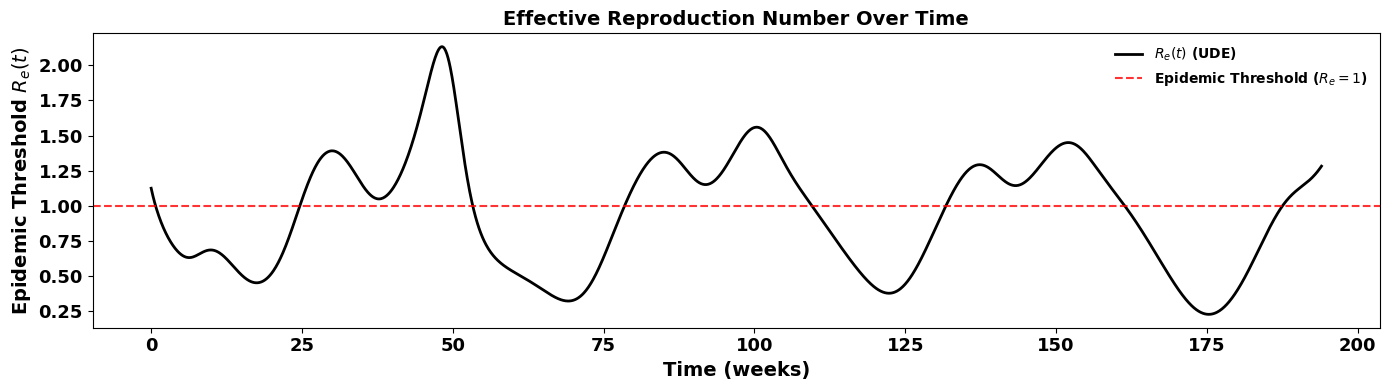

Weeks above epidemic threshold (R_e > 1): 997 / 2000


In [ ]:
# --------------------------------------------------
# BLOCK 14 : Effective Reproduction Number R_e(t)
# --------------------------------------------------

seasonal_residual_nn.eval()

with torch.no_grad():
    Re_t = []
    for i in range(len(t_fine)):
        X_state = ude_prediction[i:i+1, 0, :]
        S, I, R = X_state[0, 0].item(), X_state[0, 1].item(), X_state[0, 2].item()
        N = S + I + R + 1e-8

        t_val = t_fine_tensor[i:i+1].view(1, 1)
        beta_base = params["beta0"] * (1.0 + params["amp"] * np.cos(2 * np.pi * t_fine[i] / 52))
        res = seasonal_residual_nn(X_state, t_val).item()
        beta_eff = np.clip(beta_base + res, 0.02, 5.0)

        recovery_rate = (params["mu"] + params["alpha"] + params["delta"]
                          + params["C"] / (1 + params["d"] * I))
        Re = (beta_eff / recovery_rate) * (S / N)
        Re_t.append(Re)

Re_t = np.array(Re_t)

plt.figure(figsize=(14, 4))
plt.plot(t_fine, Re_t, "k-", linewidth=2, label=r"$R_e(t)$ (UDE)")
plt.axhline(1, color="red", linestyle="--", alpha=0.8, label="Epidemic Threshold ($R_e=1$)")
plt.title("Effective Reproduction Number Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Time (weeks)", fontsize=14, fontweight="bold")
plt.ylabel("Epidemic Threshold $R_e(t)$", fontsize=14, fontweight="bold")
plt.legend(fontsize=12, frameon=False,prop={"weight": "bold"})
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

#plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Weeks above epidemic threshold (R_e > 1): {np.sum(Re_t > 1)} / {len(Re_t)}")

Block 15: Phase Portraits (S vs I, I vs R)

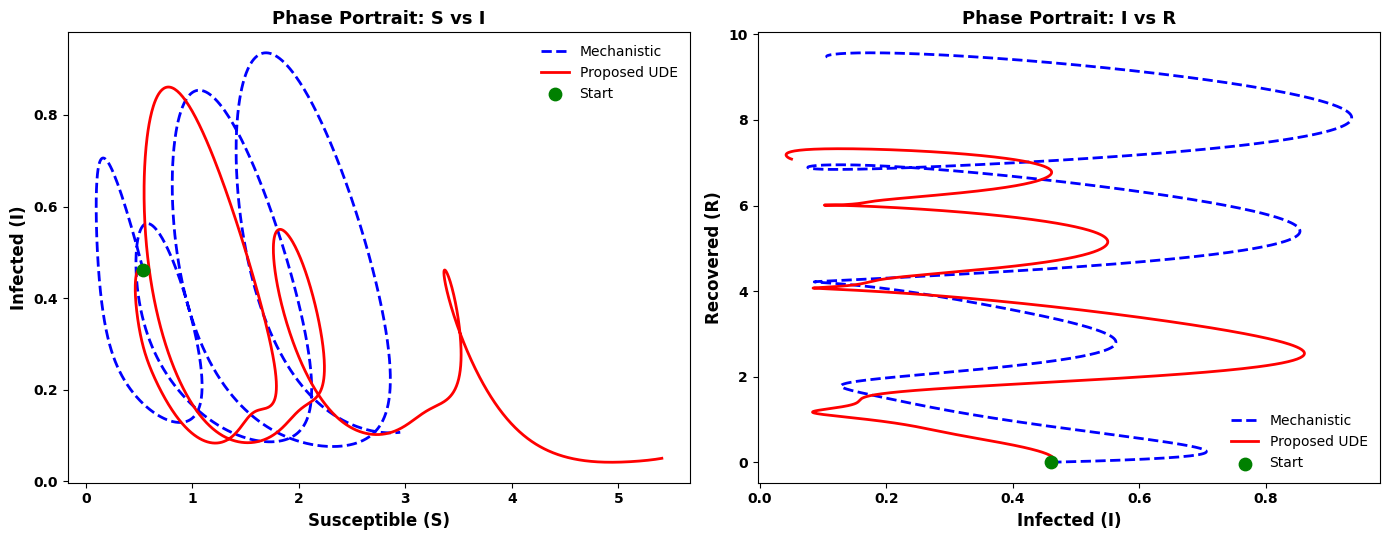

In [ ]:
# --------------------------------------------------
# BLOCK 15 : Phase Portraits
# --------------------------------------------------

S_mech = mech_prediction[:, 0].cpu().numpy()
I_mech_traj = mech_prediction[:, 1].cpu().numpy()
R_mech = mech_prediction[:, 2].cpu().numpy()

S_ude = ude_prediction[:, 0, 0].cpu().numpy()
I_ude_traj = ude_prediction[:, 0, 1].cpu().numpy()
R_ude = ude_prediction[:, 0, 2].cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].plot(S_mech, I_mech_traj, "b--", linewidth=2, label="Mechanistic")
ax[0].plot(S_ude, I_ude_traj, "r-", linewidth=2, label="Proposed UDE")
ax[0].scatter(S_ude[0], I_ude_traj[0], color="green", s=80, zorder=5, label="Start")
ax[0].set_title("Phase Portrait: S vs I", fontsize=13, fontweight="bold")
ax[0].set_xlabel("Susceptible (S)", fontsize=12, fontweight="bold")
ax[0].set_ylabel("Infected (I)", fontsize=12, fontweight="bold")
ax[0].legend(frameon=False)
plt.setp(ax[0].get_xticklabels(), fontweight="bold")
plt.setp(ax[0].get_yticklabels(), fontweight="bold")
#ax[0].grid(alpha=0.3)

ax[1].plot(I_mech_traj, R_mech, "b--", linewidth=2, label="Mechanistic")
ax[1].plot(I_ude_traj, R_ude, "r-", linewidth=2, label="Proposed UDE")
ax[1].scatter(I_ude_traj[0], R_ude[0], color="green", s=80, zorder=5, label="Start")
ax[1].set_title("Phase Portrait: I vs R", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Infected (I)", fontsize=12, fontweight="bold")
ax[1].set_ylabel("Recovered (R)", fontsize=12, fontweight="bold")
ax[1].legend(frameon=False)
plt.setp(ax[1].get_xticklabels(), fontweight="bold")
plt.setp(ax[1].get_yticklabels(), fontweight="bold")
#ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Block 16: Neural Correction Sensitivity Analysis

  scale=0.000: peak=0.9355 at week 163  (wave #4)
  scale=0.143: peak=0.8636 at week 164  (wave #4)
  scale=0.286: peak=0.7845 at week 164  (wave #4)
  scale=0.429: peak=0.7352 at week 108  (wave #3)
  scale=0.571: peak=0.7384 at week 53  (wave #2)
  scale=0.714: peak=0.7949 at week 53  (wave #2)
  scale=0.857: peak=0.8427 at week 53  (wave #2)
  scale=1.000: peak=0.8608 at week 53  (wave #2)
  scale=1.143: peak=0.8180 at week 53  (wave #2)
  scale=1.286: peak=0.7331 at week 54  (wave #2)
  scale=1.429: peak=0.7121 at week 55  (wave #2)
  scale=1.571: peak=0.7930 at week 55  (wave #2)
  scale=1.714: peak=0.8825 at week 55  (wave #2)
  scale=1.857: peak=0.9417 at week 55  (wave #2)
  scale=2.000: peak=0.9736 at week 55  (wave #2)

Waves selected as global peak across the scale sweep: [2, 3, 4]


<bound method _AxesBase.tick_params of <Axes: xlabel='Neural Correction Scale Factor ($\\lambda_{nn}$)', ylabel='Peak Infection Magnitude ($I_{max}$)'>>

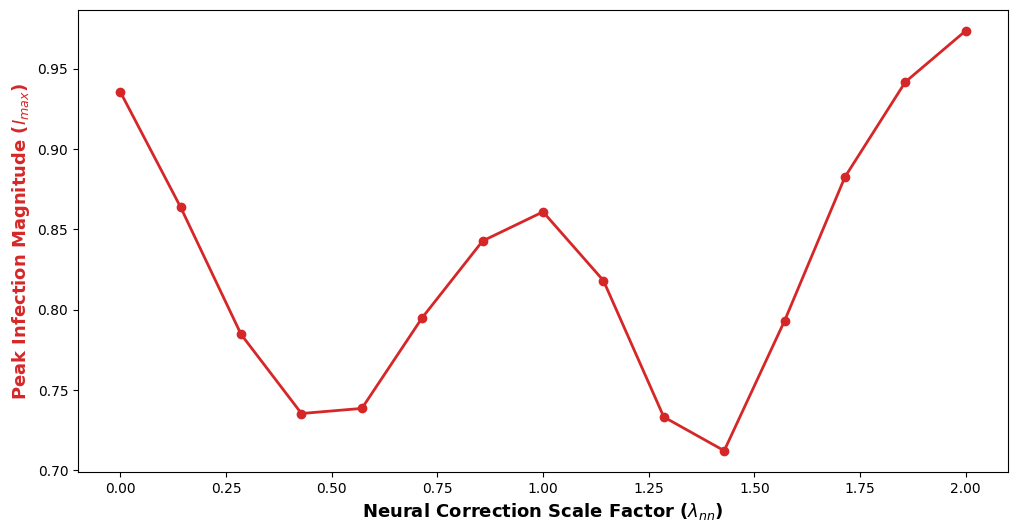

In [ ]:
# --------------------------------------------------
# BLOCK 16 (REVISED) : Neural Correction Sensitivity Analysis
# Fixes vs. previous version:
#   1. Uses dopri5 (adaptive) instead of rk4 (fixed-step) -- fixed-step
#      integration was unreliable near the beta clamp boundary [0.02, 5.0]
#      when the residual is scaled up to 2x, producing spurious jaggedness.
#   2. Tracks WHICH oscillation wave produces the peak at each scale, since
#      argmax over the full multi-wave horizon can silently jump between
#      different waves as the scale changes, mimicking a discontinuity
#      that isn't actually in the underlying dynamics.
# --------------------------------------------------

class ScaledODEFunc(nn.Module):
    def __init__(self, model, params, scale):
        super().__init__()
        self.model = model
        self.params = params
        self.scale = scale

    def forward(self, t, X):
        S, I, R = X[:,0:1], X[:,1:2], X[:,2:3]
        beta = self.params["beta0"] * (1 + self.params["amp"] * torch.cos(2 * math.pi * t / 52))
        t_input = torch.ones_like(S) * t
        residual = self.scale * self.model(X, t_input)
        beta = torch.clamp(beta + residual, 0.02, 5.0)
        N = S + I + R + 1e-8
        dS = self.params["Lambda"] - beta*S*I/N - (self.params["mu"]+self.params["nu"])*S + self.params["omega"]*R
        dI = beta*S*I/N - (self.params["mu"]+self.params["alpha"]+self.params["delta"])*I - (self.params["C"]*I)/(1+self.params["d"]*I)
        dR = self.params["alpha"]*I - (self.params["mu"]+self.params["omega"])*R + self.params["nu"]*S + (self.params["C"]*I)/(1+self.params["d"]*I)
        return torch.cat([dS,dI,dR],dim=1)

seasonal_residual_nn.eval()

nn_scales = np.linspace(0.0, 2.0, 15)
peak_magnitudes = []
peak_weeks = []
peak_wave_numbers = []   # NEW: diagnostic -- which ~52-week cycle the peak fell in

with torch.no_grad():
    for scale in nn_scales:
        scaled_func = ScaledODEFunc(seasonal_residual_nn, params, scale).to(device)
        # FIX 1: dopri5 (adaptive) instead of rk4 (fixed-step)
        pred = odeint(scaled_func, X0, t_fine_tensor, method="dopri5")
        if pred.dim() == 3: pred = pred.squeeze(1)
        I_traj = pred[:, 1].cpu().numpy()

        peak_idx = np.argmax(I_traj)
        wave_number = int(t_fine[peak_idx] // 52) + 1   # FIX 2: track which wave

        peak_magnitudes.append(I_traj[peak_idx])
        peak_weeks.append(t_fine[peak_idx])
        peak_wave_numbers.append(wave_number)

        print(f"  scale={scale:.3f}: peak={I_traj[peak_idx]:.4f} at week "
              f"{t_fine[peak_idx]:.0f}  (wave #{wave_number})")

# --------------------------------------------------
# Diagnostic check: did the peak silently jump between different waves?
# If wave_number is constant (or changes smoothly/monotonically), the
# curve reflects genuine dynamics. If it jumps around non-monotonically,
# the "peak timing" plot below is partly an artifact of wave-switching,
# not a real discontinuity in the model's response to scale.
# --------------------------------------------------
unique_waves = sorted(set(peak_wave_numbers))
print(f"\nWaves selected as global peak across the scale sweep: {unique_waves}")
if len(unique_waves) > 1:
    print("WARNING: the global peak jumps between different oscillation waves "
          "as scale changes. Peak-timing discontinuities below may partly "
          "reflect this wave-switching rather than a genuine dynamical "
          "discontinuity. Consider restricting peak search to a single "
          "consistent wave (e.g., the first) if you want a strictly "
          "comparable timing metric across scales -- see alternative block below.")

fig, ax1 = plt.subplots(figsize=(12, 6))

color = "tab:red"
ax1.set_xlabel(r"Neural Correction Scale Factor ($\lambda_{nn}$)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Peak Infection Magnitude ($I_{max}$)", color=color, fontsize=13, fontweight="bold")
ax1.plot(nn_scales, peak_magnitudes, color=color, linewidth=2, marker="o")
ax1.tick_params

Block 17: Multi-Region Data Preparation

In [ ]:
import os

# --------------------------------------------------
# BLOCK 17 (REVISED) : Real Regional Data — Config & Loading
# --------------------------------------------------

REGION_FILES = {
    "Bay Area":     "/content/Bay_Area.csv",
    "Central": "/content/Central.csv",
    "Northern":   "/content/Northern.csv",
    "Upper Southern ":   "/content/Upper_Southern.csv",
    "Lower Southern ":   "/content/Lower_Southern.csv",
}
# EDIT the paths above to match your actual filenames.
# Each file is assumed to have the SAME columns as California.csv:
#   a date column named "weekending" and a count column named "Total_ILI".
# If your columns are named differently, change DATE_COL / VALUE_COL below.

DATE_COL = "weekending"
VALUE_COL = "Total_ILI"

region_data = {}

for name, path in REGION_FILES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing regional file for '{name}': {path}\n"
            f"Update REGION_FILES with the correct path before continuing."
        )
    df_r = pd.read_csv(path)
    df_r[DATE_COL] = pd.to_datetime(df_r[DATE_COL], format="mixed")
    df_r = df_r.sort_values(DATE_COL).reset_index(drop=True)

    t_r = (df_r[DATE_COL] - df_r[DATE_COL].iloc[0]).dt.days.values / 7
    I_r = df_r[VALUE_COL].values.astype(np.float32)
    I_r = I_r / np.max(I_r)

    region_data[name] = {"t": t_r.astype(np.float32), "I": I_r}

print("Loaded regional data:")
for name, d in region_data.items():
    print(f"  {name:8s}: {len(d['I'])} weeks, range [{d['I'].min():.3f}, {d['I'].max():.3f}]")

Loaded regional data:
  Bay Area: 195 weeks, range [0.115, 1.000]
  Central : 195 weeks, range [0.000, 1.000]
  Northern: 195 weeks, range [0.007, 1.000]
  Upper Southern : 195 weeks, range [0.000, 1.000]
  Lower Southern : 195 weeks, range [0.010, 1.000]


Insert a new cell between these two — after data loads, before any training happens. This is Block 17.5:

In [ ]:
# --------------------------------------------------
# BLOCK 17.5 (REVISED) : Detect near-zero / low-incidence regime,
# not just exact zeros. Runs BEFORE Block 20's train/test split.
# --------------------------------------------------

def diagnose_low_incidence(name, t_arr, I_arr, rel_threshold=0.03, min_run_length=10):
    """Flags a REGIME, not just literal zeros: any stretch of weeks where
    incidence stays below rel_threshold * max(I) for at least min_run_length
    consecutive weeks. This catches near-zero reporting collapses that
    exact-zero detection misses."""
    threshold = rel_threshold * np.max(I_arr)
    is_low = I_arr <= threshold

    n = len(I_arr)
    i = 0
    runs = []
    while i < n:
        if is_low[i]:
            j = i
            while j < n and is_low[j]:
                j += 1
            runs.append((i, j))
            i = j
        else:
            i += 1

    print(f"  {name}: threshold={threshold:.4f} (={rel_threshold*100:.0f}% of max)")
    for (start, end) in runs:
        length = end - start
        flag = " <- LOW-INCIDENCE REGIME" if length >= min_run_length else ""
        print(f"    weeks {t_arr[start]:.0f}-{t_arr[end-1]:.0f} ({length} weeks){flag}")

    # Return the START of the LAST such regime if it runs to the end of series
    # (i.e., a genuine trailing collapse, not a mid-series dip)
    if runs:
        last_start, last_end = runs[-1]
        if last_end == n and (last_end - last_start) >= min_run_length:
            return t_arr[last_start]
    return None

print("=== Low-incidence regime diagnostics (relative threshold, all regions) ===")
regime_starts = {}
for name, d in region_data.items():
    regime_start = diagnose_low_incidence(name, d["t"], d["I"], rel_threshold=0.03, min_run_length=10)
    regime_starts[name] = regime_start

# --------------------------------------------------
# Apply truncation ONLY where a trailing low-incidence regime was found
# (data-driven, not selectively applied to make any one region "look better")
# --------------------------------------------------

for name, regime_start in regime_starts.items():
    if regime_start is not None:
        d = region_data[name]
        mask = d["t"] < regime_start
        n_dropped = (~mask).sum()
        print(f"\n{name}: trailing low-incidence regime starts at week {regime_start:.0f} "
              f"-> dropping {n_dropped} trailing weeks")
        t_trim = d["t"][mask]
        I_trim = d["I"][mask]
        region_data[name]["t"] = t_trim
        region_data[name]["I"] = I_trim / np.max(I_trim)   # renormalize after truncation
    else:
        print(f"\n{name}: no trailing low-incidence regime detected -- kept as-is.")

print("\nFinal region lengths after low-incidence handling:")
for name, d in region_data.items():
    print(f"  {name:8s}: {len(d['I'])} weeks")

=== Low-incidence regime diagnostics (relative threshold, all regions) ===
  Bay Area: threshold=0.0300 (=3% of max)
  Central: threshold=0.0300 (=3% of max)
    weeks 143-147 (5 weeks)
    weeks 149-152 (4 weeks)
    weeks 154-156 (3 weeks)
    weeks 166-194 (29 weeks) <- LOW-INCIDENCE REGIME
  Northern: threshold=0.0300 (=3% of max)
    weeks 141-142 (2 weeks)
  Upper Southern : threshold=0.0300 (=3% of max)
    weeks 23-24 (2 weeks)
    weeks 28-33 (6 weeks)
    weeks 35-36 (2 weeks)
    weeks 72-72 (1 weeks)
    weeks 74-84 (11 weeks) <- LOW-INCIDENCE REGIME
    weeks 90-90 (1 weeks)
    weeks 125-125 (1 weeks)
    weeks 127-128 (2 weeks)
    weeks 130-134 (5 weeks)
    weeks 136-142 (7 weeks)
    weeks 170-174 (5 weeks)
    weeks 176-194 (19 weeks) <- LOW-INCIDENCE REGIME
  Lower Southern : threshold=0.0300 (=3% of max)
    weeks 26-26 (1 weeks)
    weeks 172-176 (5 weeks)
    weeks 178-184 (7 weeks)

Bay Area: no trailing low-incidence regime detected -- kept as-is.

Central: tra

Block 18: Regularized UDE Training Function

In [ ]:
# --------------------------------------------------
# BLOCK 18 : Regularized UDE Training Function
# L(phi) = L_data + lambda_r * L_reg   (Eqs. 15-17 in the paper)
# --------------------------------------------------

def train_ude_regularized(t_arr, I_arr, params, lam_r=1e-3, epochs=300,
                           lr=5e-4, seed=None, init_state_dict=None, verbose=False):
    """
    Trains a SeasonalResidualNN + ODEFunc on a given (t, I) series with
    residual regularization strength lam_r.
    Returns: model, ode_func, X0_local, t_tensor_local, loss_history
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    I0_l = I_arr[0]
    R0_l = 0.0
    S0_l = 1.0 - I0_l - R0_l
    X0_local = torch.tensor([[S0_l, I0_l, R0_l]], dtype=torch.float32, device=device)

    t_tensor_local = torch.tensor(t_arr, dtype=torch.float32, device=device)
    I_tensor_local = torch.tensor(I_arr, dtype=torch.float32, device=device)

    local_model = SeasonalResidualNN().to(device)
    if init_state_dict is not None:
        local_model.load_state_dict(copy.deepcopy(init_state_dict))

    local_ode_func = ODEFunc(local_model, params).to(device)
    optimizer_l = optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-5)

    loss_hist = []

    for epoch in range(epochs):
        optimizer_l.zero_grad()

        pred_X = odeint(local_ode_func, X0_local, t_tensor_local, method="rk4")
        if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

        loss_data = F.mse_loss(pred_X[:, 1], I_tensor_local)

        # --- Residual regularization: penalize |delta_beta_phi(S,I,R)| ---
        with torch.enable_grad():
            beta_base = params["beta0"] * (1 + params["amp"] *
                         torch.cos(2 * math.pi * t_tensor_local.unsqueeze(1) / 52))
            residual = local_model(pred_X, t_tensor_local.unsqueeze(1))
            loss_reg = torch.mean(residual ** 2)

        loss = loss_data + lam_r * loss_reg
        loss.backward()
        torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
        optimizer_l.step()

        loss_hist.append(loss.item())
        if verbose and epoch % 50 == 0:
            print(f"    Epoch {epoch:3d} | Loss={loss.item():.6f} | "
                  f"L_data={loss_data.item():.6f} | L_reg={loss_reg.item():.6f}")

    return local_model, local_ode_func, X0_local, t_tensor_local, loss_hist


import copy
print("train_ude_regularized() defined.")

train_ude_regularized() defined.


Block 19: Multi-Region Source Pretraining

In [ ]:
# --------------------------------------------------
# BLOCK 19 : Multi-Region Source Pretraining
# Pretrain a shared residual model phi* on POOLED source regions
# --------------------------------------------------

def pretrain_source_model(source_names, params, lam_r=1e-3, epochs=300, seed=0):
    """Pools the (t, I) series of all source regions into one combined
    training set and trains a shared SeasonalResidualNN on it."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    pooled_model = SeasonalResidualNN().to(device)
    pooled_optimizer = optim.AdamW(pooled_model.parameters(), lr=5e-4, weight_decay=1e-5)
    loss_hist = []

    # Pre-build per-region tensors
    region_tensors = {}
    for name in source_names:
        d = region_data[name]
        I0_r, R0_r = d["I"][0], 0.0
        S0_r = 1.0 - I0_r - R0_r
        X0_r = torch.tensor([[S0_r, I0_r, R0_r]], dtype=torch.float32, device=device)
        t_r = torch.tensor(d["t"], dtype=torch.float32, device=device)
        I_r = torch.tensor(d["I"], dtype=torch.float32, device=device)
        region_tensors[name] = (X0_r, t_r, I_r)

    for epoch in range(epochs):
        pooled_optimizer.zero_grad()
        total_loss = 0.0

        for name in source_names:
            X0_r, t_r, I_r = region_tensors[name]
            ode_func_r = ODEFunc(pooled_model, params).to(device)
            pred_X = odeint(ode_func_r, X0_r, t_r, method="rk4")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)

            loss_data = F.mse_loss(pred_X[:, 1], I_r)
            residual = pooled_model(pred_X, t_r.unsqueeze(1))
            loss_reg = torch.mean(residual ** 2)

            total_loss = total_loss + loss_data + lam_r * loss_reg

        total_loss = total_loss / len(source_names)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(pooled_model.parameters(), 1.0)
        pooled_optimizer.step()

        loss_hist.append(total_loss.item())
        if epoch % 50 == 0:
            print(f"  [Source Pretrain] Epoch {epoch:3d} | Pooled Loss: {total_loss.item():.6f}")

    return pooled_model, loss_hist

Block 20 (revised): LORO with fixed split + real ensemble diversity

In [ ]:
# --------------------------------------------------
# BLOCK 20 (FINAL) : LORO — 75/25 Chronological Split + Genuine Ensemble CI
# --------------------------------------------------

TRAIN_FRACTION = 0.75
LAM_R = 1e-3
SOURCE_EPOCHS = 200
FINETUNE_EPOCHS = 150
N_ENSEMBLE = 8
WEIGHT_NOISE_SCALE = 0.02
SUBSAMPLE_FRAC = 0.85

def perturb_state_dict(state_dict, noise_scale, seed):
    torch.manual_seed(seed)
    perturbed = {}
    for k, v in state_dict.items():
        perturbed[k] = v + torch.randn_like(v) * noise_scale
    return perturbed

def subsample_weeks(t_arr, I_arr, frac, seed):
    rng = np.random.RandomState(seed)
    n = len(t_arr)
    k = max(8, int(n * frac))
    k = min(k, n)
    idx = np.sort(rng.choice(n, size=k, replace=False))
    return t_arr[idx], I_arr[idx]

def compute_metrics_arr(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    smape = np.mean(2*np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    return rmse, mae, mape, smape

region_names = list(region_data.keys())
main_results = []
main_predictions = {}

for target_name in region_names:
    print(f"\n=== Target Region: {target_name} ===")
    source_names = [n for n in region_names if n != target_name]

    d = region_data[target_name]
    t_full = d["t"]
    I_full = d["I"]
    n_total = len(I_full)

    # --- 75/25 chronological split ---
    split_idx = int(round(n_total * TRAIN_FRACTION))
    split_idx = max(10, min(split_idx, n_total - 5))
    split_week = t_full[split_idx]
    n_train = split_idx
    n_test = n_total - split_idx

    print(f"  Retained series length: {n_total} weeks "
          f"(post-truncation, per Block 17.5 if applicable to this region)")
    print(f"  Split: {n_train} training weeks / {n_test} testing weeks "
          f"({n_train}/{n_total} = {100*n_train/n_total:.1f}% train)")

    t_train, I_train = t_full[:split_idx], I_full[:split_idx]

    # --- Step 1: Pretrain shared residual on SOURCE regions ---
    phi_star, _ = pretrain_source_model(source_names, params, lam_r=LAM_R,
                                         epochs=SOURCE_EPOCHS, seed=1234)
    phi_star_state = phi_star.state_dict()

    # --- Step 2: Genuinely diverse ensemble fine-tune on TRAIN portion ---
    ensemble_preds = []
    ensemble_state_dicts = []
    for seed in range(N_ENSEMBLE):
        t_sub, I_sub = subsample_weeks(t_train, I_train, SUBSAMPLE_FRAC, seed)
        perturbed_init = perturb_state_dict(phi_star_state, WEIGHT_NOISE_SCALE, seed)

        model_e, ode_func_e, X0_e, _, _ = train_ude_regularized(
            t_sub, I_sub, params, lam_r=LAM_R, epochs=FINETUNE_EPOCHS,
            lr=3e-4, seed=seed, init_state_dict=perturbed_init
        )
        model_e.eval()
        with torch.no_grad():
            t_full_tensor = torch.tensor(t_full, dtype=torch.float32, device=device)
            pred_X = odeint(ode_func_e, X0_e, t_full_tensor, method="dopri5")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
            ensemble_preds.append(pred_X[:, 1].cpu().numpy())
            ensemble_state_dicts.append(copy.deepcopy(model_e.state_dict()))

    ensemble_preds = np.stack(ensemble_preds, axis=0)
    pred_mean = ensemble_preds.mean(axis=0)
    pred_std = ensemble_preds.std(axis=0)
    ci_lo = np.maximum(pred_mean - 1.96 * pred_std, 0.0)
    ci_hi = pred_mean + 1.96 * pred_std

    print(f"  Ensemble spread check — mean std across forecast weeks: "
          f"{pred_std[split_idx:].mean():.5f}  (should be clearly > 0)")

    # --- Held-out RMSE/MAE/MAPE/sMAPE on the ACTUAL held-out 25% only ---
    obs_forecast = I_full[split_idx:]
    pred_forecast = pred_mean[split_idx:]
    rmse_f, mae_f, mape_f, smape_f = compute_metrics_arr(obs_forecast, pred_forecast)

    main_results.append({
        "Region": target_name, "N_train": n_train, "N_test": n_test,
        "Split Week": split_week, "RMSE": rmse_f, "MAE": mae_f,
        "MAPE (%)": mape_f, "sMAPE (%)": smape_f
    })

    main_predictions[target_name] = {
        "t": t_full, "obs": I_full, "split_idx": split_idx, "split_week": split_week,
        "pred_mean": pred_mean, "ci_lo": ci_lo, "ci_hi": ci_hi,
        "ensemble_state_dicts": ensemble_state_dicts,
        "phi_star_state": copy.deepcopy(phi_star_state),
        "t_train": t_train, "I_train": I_train,
        "n_total": n_total,   # <-- NEW: retained series length, for Block 25's audit table
    }

    print(f"  Held-out RMSE={rmse_f:.4f} MAE={mae_f:.4f} MAPE={mape_f:.2f}% sMAPE={smape_f:.2f}%")

main_results_df = pd.DataFrame(main_results)
avg_row = main_results_df.mean(numeric_only=True).to_dict()
avg_row["Region"] = "Average"
main_results_df = pd.concat([main_results_df, pd.DataFrame([avg_row])], ignore_index=True)

print("\n--- Held-Out (75/25) Forecast Performance ---")
print(main_results_df.round(4).to_string(index=False))


=== Target Region: Bay Area ===
  Retained series length: 195 weeks (post-truncation, per Block 17.5 if applicable to this region)
  Split: 146 training weeks / 49 testing weeks (146/195 = 74.9% train)
  [Source Pretrain] Epoch   0 | Pooled Loss: 0.054837
  [Source Pretrain] Epoch  50 | Pooled Loss: 0.028280
  [Source Pretrain] Epoch 100 | Pooled Loss: 0.019280
  [Source Pretrain] Epoch 150 | Pooled Loss: 0.016187
  Ensemble spread check — mean std across forecast weeks: 0.05421  (should be clearly > 0)
  Held-out RMSE=0.1654 MAE=0.1283 MAPE=64.90% sMAPE=40.15%

=== Target Region: Central ===
  Retained series length: 166 weeks (post-truncation, per Block 17.5 if applicable to this region)
  Split: 124 training weeks / 42 testing weeks (124/166 = 74.7% train)
  [Source Pretrain] Epoch   0 | Pooled Loss: 0.048564
  [Source Pretrain] Epoch  50 | Pooled Loss: 0.034830
  [Source Pretrain] Epoch 100 | Pooled Loss: 0.032443
  [Source Pretrain] Epoch 150 | Pooled Loss: 0.023112
  Ensemble sp

Block 21 (revised): Figure 3 — LORO held-out forecast, CI now visible

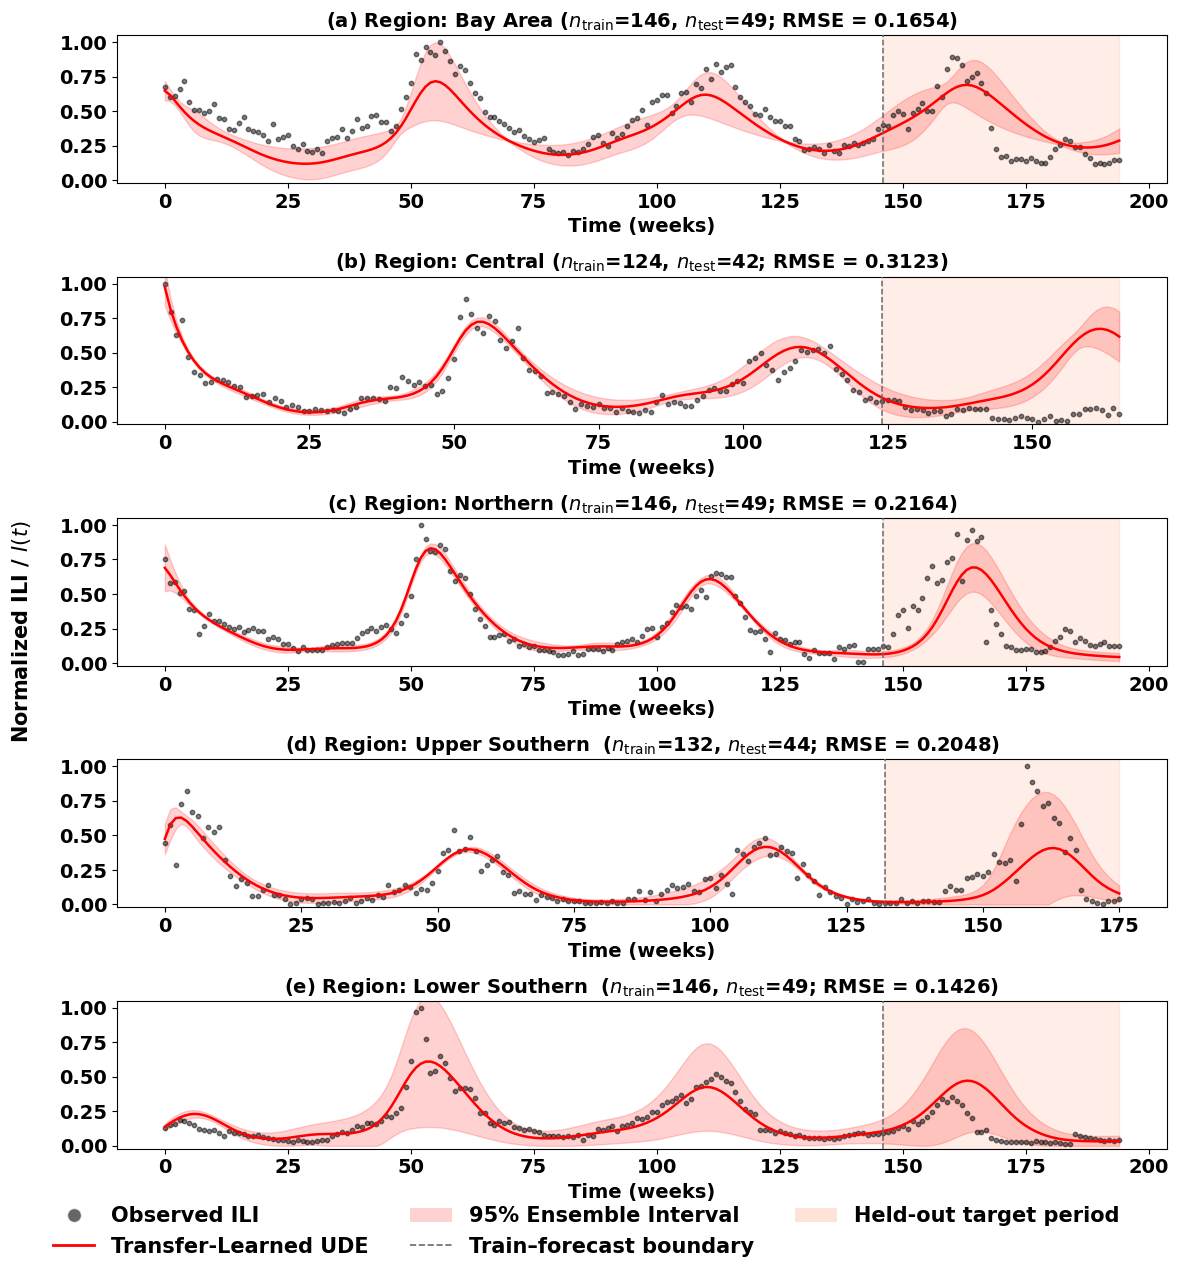


=== Table: Held-Out (75/25) Forecast Performance by Region ===


,Region,N_train,N_test,Split Week,RMSE,MAE,MAPE (%),sMAPE (%)
0,Bay Area,146.000000,49.000000,146,0.1654,0.1283,64.90%,40.15%
1,Central,124.000000,42.000000,124,0.3123,0.2250,71557032.00%,104.81%
2,Northern,146.000000,49.000000,146,0.2164,0.1851,80.24%,75.14%
3,Upper Southern,132.000000,44.000000,132,0.2048,0.1422,200.17%,78.55%
4,Lower Southern,146.000000,49.000000,146,0.1426,0.0975,189.52%,69.05%
5,Average,138.800000,46.600000,139,0.2083,0.1557,14311514.00%,73.54%


In [ ]:
# --------------------------------------------------
# BLOCK 21 (FINAL) : Fig. 8 — LORO Held-Out Forecasting
# Single-column stacked panels (a)-(e). Font sizes: title/xlabel/ylabel=15,
# xtick/ytick/legend=14.
# --------------------------------------------------

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

n_regions = len(region_names)
fig, axes = plt.subplots(n_regions, 1, figsize=(12, 2.6 * n_regions), sharex=False)

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

for i, name in enumerate(region_names):
    d = main_predictions[name]
    ax = axes[i]
    split_idx = d["split_idx"]
    split_week = d["split_week"]
    t_arr = d["t"]

    ci_lo_clipped = np.maximum(d["ci_lo"], 0.0)

    ax.axvspan(split_week, t_arr[-1], color="orangered", alpha=0.09, zorder=0)
    ax.scatter(t_arr, d["obs"], color="black", s=10, alpha=0.5, zorder=3)
    ax.plot(t_arr, d["pred_mean"], "r-", linewidth=1.8, zorder=4)
    ax.fill_between(t_arr, ci_lo_clipped, d["ci_hi"], color="red", alpha=0.18, zorder=2)
    ax.axvline(split_week, color="dimgray", linestyle="--", linewidth=1.1, zorder=5)

    n_train, n_test = split_idx, len(t_arr) - split_idx
    rmse_i = main_results_df.loc[main_results_df["Region"] == name, "RMSE"].values[0]
    ax.set_title(
        f"{panel_labels[i]} Region: {name} "
        f"($n_{{\\mathrm{{train}}}}$={n_train}, $n_{{\\mathrm{{test}}}}$={n_test}; "
        f"RMSE = {rmse_i:.4f})",
        fontsize=14, fontweight="bold", loc="center"
    )
    ax.set_ylim(-0.02, 1.05)

    ax.set_xlabel("Time (weeks)", fontsize=14, fontweight="bold")
    plt.setp(ax.get_xticklabels(), fontweight="bold", fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight="bold", fontsize=14)

fig.text(0.02, 0.5, r"Normalized ILI / $I(t)$",
          va="center", rotation="vertical", fontsize=15, fontweight="bold")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", alpha=0.6,
           markersize=10, label="Observed ILI"),
    Line2D([0], [0], color="red", linewidth=2, label="Transfer-Learned UDE"),
    Patch(facecolor="red", alpha=0.18, label="95% Ensemble Interval"),
    Line2D([0], [0], color="dimgray", linestyle="--", linewidth=1.2, label="Train–forecast boundary"),
    Patch(facecolor="orangered", alpha=0.15, label="Held-out target period"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.005), prop={"size":15,"weight": "bold"})

#fig.suptitle("Transfer-Learned UDE Forecasting under Leave-One-Region-Out Evaluation", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(rect=[0.06, 0.05, 1, 0.99])
plt.savefig("figure8_loro_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

display_df = main_results_df.copy()
display_df.columns = ["Region", "N_train", "N_test", "Split Week", "RMSE", "MAE", "MAPE (%)", "sMAPE (%)"]
print("\n=== Table: Held-Out (75/25) Forecast Performance by Region ===")
display(display_df.style.format({
    "Split Week": "{:.0f}", "RMSE": "{:.4f}", "MAE": "{:.4f}",
    "MAPE (%)": "{:.2f}%", "sMAPE (%)": "{:.2f}%"
}).background_gradient(cmap="RdYlGn_r", subset=["RMSE", "MAE", "MAPE (%)", "sMAPE (%)"]))

Block 22: External Validation on Aggregate California (Fig. 14)

This reuses your existing single-region California fit (Blocks 8/10) — it's the natural "external validation" since California itself is the aggregate of the five regions.

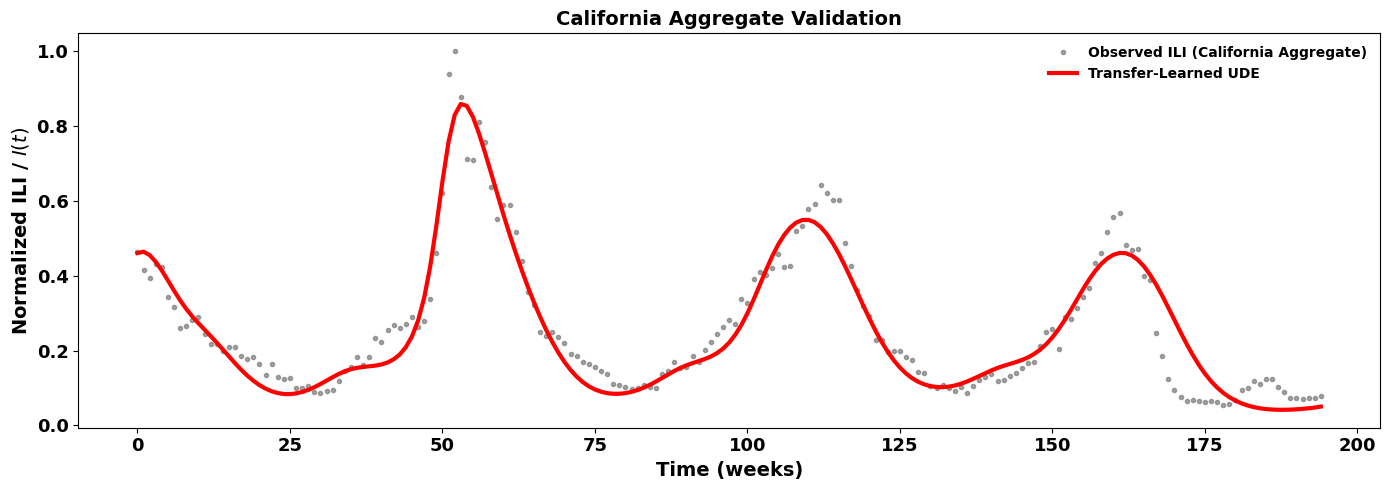

California Aggregate — RMSE: 0.0578 | MAE: 0.0427 | MAPE: 24.20% | sMAPE: 22.60%


In [ ]:
# --------------------------------------------------
# BLOCK 22 : External Validation — California Aggregate
# --------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(t_data, I_obs, ".",color="dimgray", alpha=0.6, markersize=6, label="Observed ILI (California Aggregate)")
plt.plot(t_data, I_ude, color="red", linewidth=3, label="Transfer-Learned UDE")
plt.title("California Aggregate Validation", fontsize=14, fontweight="bold")
plt.xlabel("Time (weeks)", fontsize=14, fontweight="bold")
plt.ylabel(r"Normalized ILI / $I(t)$", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", frameon=False,prop={"weight": "bold"})
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

rmse_ca, mae_ca, mape_ca, smape_ca = compute_metrics_arr(I_obs, I_ude)
print(f"California Aggregate — RMSE: {rmse_ca:.4f} | MAE: {mae_ca:.4f} | "
      f"MAPE: {mape_ca:.2f}% | sMAPE: {smape_ca:.2f}%")

Block 23a: Prospective Future Forecast — California Aggregate



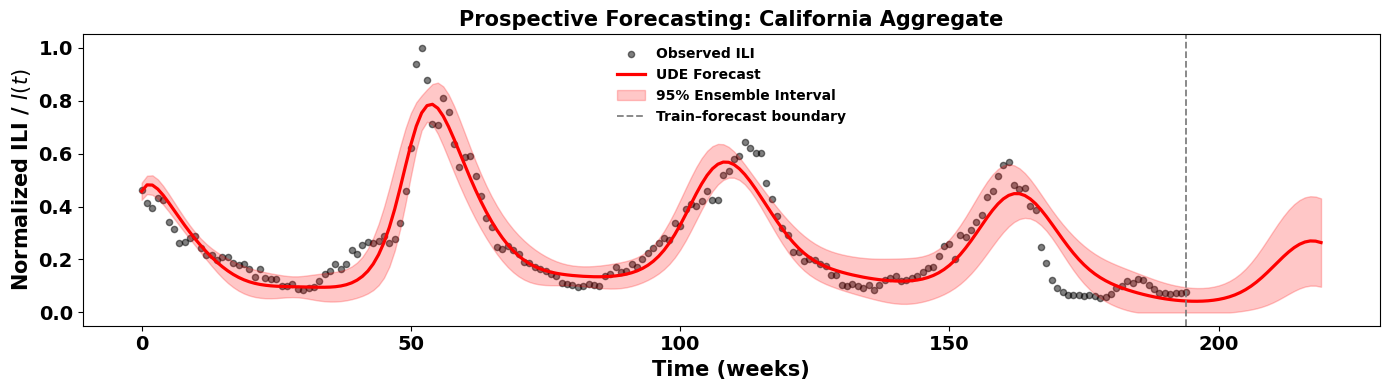

Prospective forecast window: weeks 195 to 219 (25 weeks beyond last observation)
NOTE: No ground truth exists in this window. This is a forward projection,
not a validated forecast -- report it as such.


In [ ]:
# --------------------------------------------------
# BLOCK 23a : Prospective Future Forecast — California Aggregate
# Trained on ALL available data (0 to last week). No held-out validation
# here — this is forward-looking projection only, clearly separated from
# Figure 3 (LORO held-out validation).
# --------------------------------------------------

FUTURE_HORIZON_WEEKS = 25   # conservative, per recommendation (20-30 weeks)

def prospective_forecast(t_arr, I_arr, params, horizon_weeks, n_ensemble=8,
                          noise_scale=0.02, subsample_frac=0.9, epochs=200, lam_r=1e-3):
    """Trains a final ensemble on the FULL series, then projects forward
    horizon_weeks beyond the last observed week. No ground truth exists
    beyond the last observed week -- this is projection, not validation."""

    last_week = t_arr[-1]
    t_future_extra = np.arange(last_week + 1, last_week + horizon_weeks + 1, dtype=np.float32)
    t_plot = np.concatenate([t_arr, t_future_extra])

    ensemble_preds = []
    for seed in range(n_ensemble):
        t_sub, I_sub = subsample_weeks(t_arr, I_arr, subsample_frac, seed)
        model_e, ode_func_e, X0_e, _, _ = train_ude_regularized(
            t_sub, I_sub, params, lam_r=lam_r, epochs=epochs,
            lr=3e-4, seed=seed, init_state_dict=None
        )
        model_e.eval()
        with torch.no_grad():
            t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32, device=device)
            pred_X = odeint(ode_func_e, X0_e, t_plot_tensor, method="dopri5")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
            ensemble_preds.append(pred_X[:, 1].cpu().numpy())

    ensemble_preds = np.stack(ensemble_preds, axis=0)
    pred_mean = ensemble_preds.mean(axis=0)
    pred_std = ensemble_preds.std(axis=0)
    ci_lo = np.maximum(pred_mean - 1.96 * pred_std, 0.0)
    ci_hi = pred_mean + 1.96 * pred_std

    return t_plot, pred_mean, ci_lo, ci_hi, len(t_arr)

# --- Run on the California aggregate (primary series) ---
t_plot_ca, pred_mean_ca, ci_lo_ca, ci_hi_ca, n_obs_ca = prospective_forecast(
    t_data, I_obs, params, FUTURE_HORIZON_WEEKS
)

plt.figure(figsize=(14, 4))
plt.scatter(t_data, I_obs, color="black", s=20, alpha=0.5, label="Observed ILI")
plt.plot(t_plot_ca, pred_mean_ca, "r-", linewidth=2.3, label="UDE Forecast")
plt.fill_between(t_plot_ca, ci_lo_ca, ci_hi_ca, color="red", alpha=0.22, label="95% Ensemble Interval")
plt.axvline(t_data[-1], color="gray", linestyle="--", linewidth=1.3, label="Train–forecast boundary")

plt.title("Prospective Forecasting: California Aggregate",
          fontsize=15, fontweight="bold")
plt.xlabel("Time (weeks)", fontsize=15, fontweight="bold")
plt.ylabel(r"Normalized ILI / $I(t)$", fontsize=15, fontweight="bold")
plt.legend(loc="upper center", fontsize=14, frameon=False, prop={"weight": "bold"})
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figure4_prospective_forecast_california.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Prospective forecast window: weeks {int(t_data[-1])+1} to {int(t_plot_ca[-1])} "
      f"({FUTURE_HORIZON_WEEKS} weeks beyond last observation)")
print("NOTE: No ground truth exists in this window. This is a forward projection,")
print("not a validated forecast -- report it as such.")

Block 23b: Prospective Future Forecast — Per Region (Warm-Started from Block 20)

=== Prospective Forecast (warm-start): Bay Area ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Central ===
  Forecast window: weeks 166 to 190
=== Prospective Forecast (warm-start): Northern ===
  Forecast window: weeks 195 to 219
=== Prospective Forecast (warm-start): Upper Southern  ===
  Forecast window: weeks 176 to 200
=== Prospective Forecast (warm-start): Lower Southern  ===
  Forecast window: weeks 195 to 219


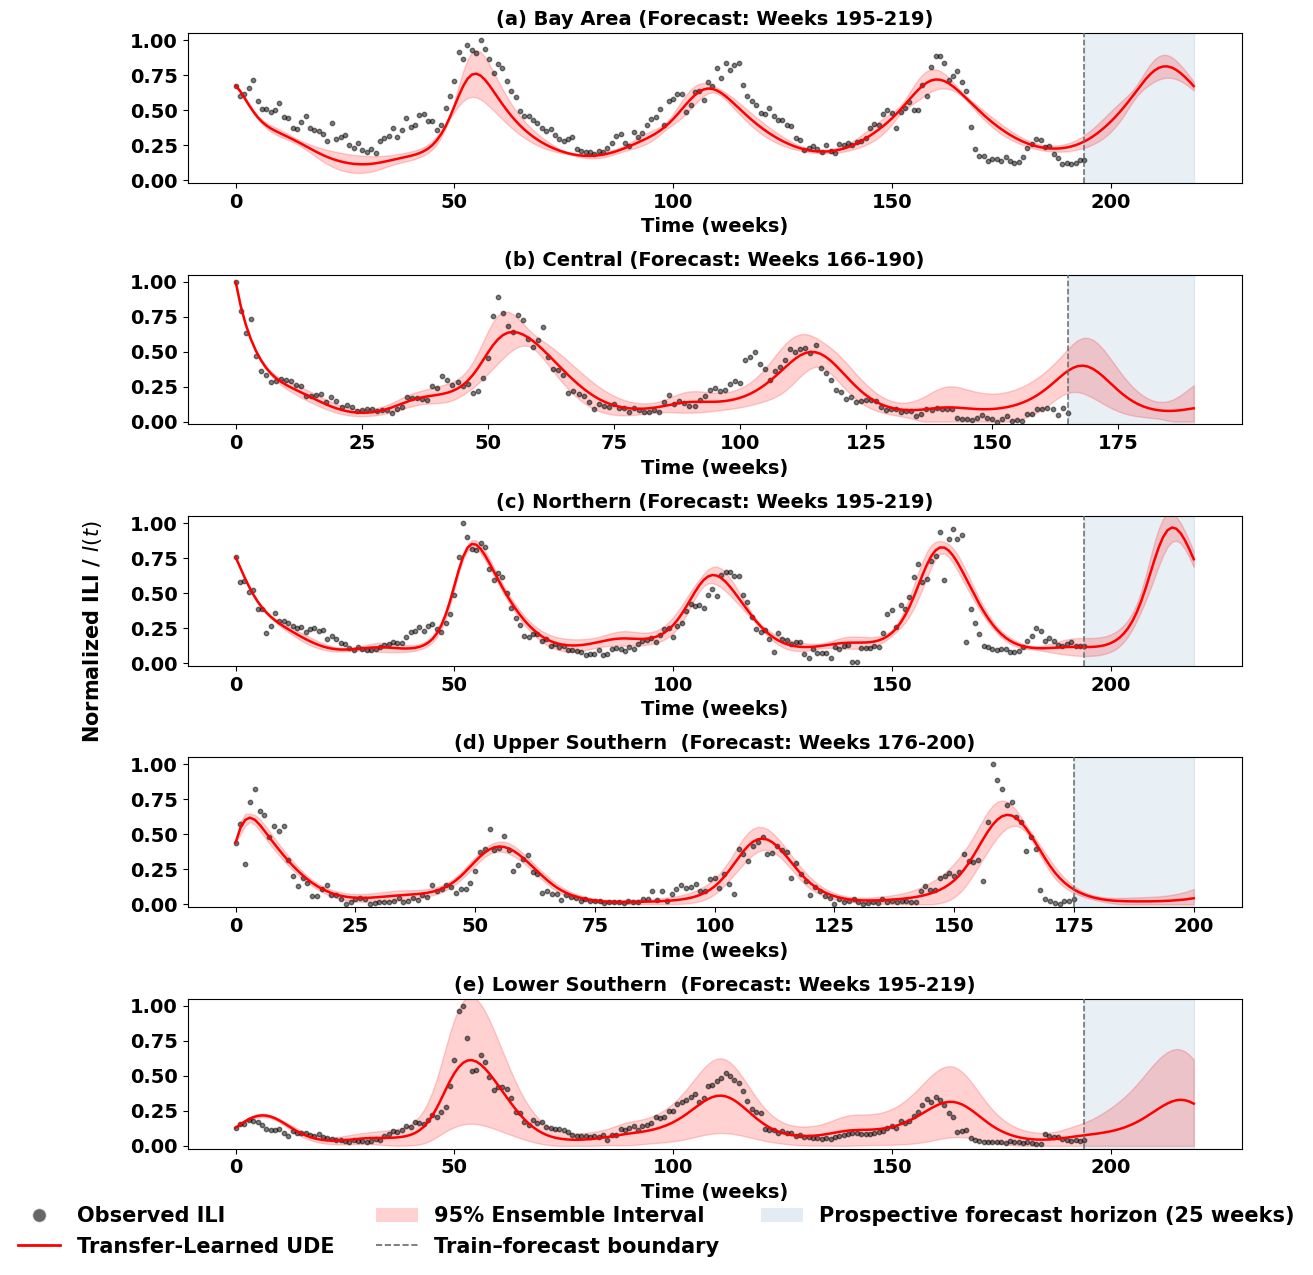


NOTE: No ground truth exists beyond each region's last observed week.
These are forward projections, not validated forecasts -- report them as such.


In [ ]:
# --------------------------------------------------
# BLOCK 23b (FINAL) : Fig. 11 — Prospective Regional Forecasting
# Reuses ensemble models already trained in Block 20 (warm start) --
# only briefly fine-tunes on the FULL series before projecting forward.
# Single-column stacked panels (a)-(e). Font sizes: title/xlabel/ylabel=15,
# xtick/ytick/legend=14.
# --------------------------------------------------

FINAL_FINETUNE_EPOCHS = 40

def warm_start_prospective_forecast(t_full, I_full, params, horizon_weeks,
                                     ensemble_state_dicts, lam_r=1e-3,
                                     finetune_epochs=FINAL_FINETUNE_EPOCHS, lr=2e-4):
    """Takes the already-trained ensemble from Block 20 (trained on the 75%
    split), briefly fine-tunes each member on the FULL series (adding back
    the held-out 25%), then projects forward. Much cheaper than retraining
    from scratch."""
    last_week = t_full[-1]
    t_future_extra = np.arange(last_week + 1, last_week + horizon_weeks + 1, dtype=np.float32)
    t_plot = np.concatenate([t_full, t_future_extra])
    t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32, device=device)

    ensemble_preds = []
    for state_dict in ensemble_state_dicts:
        model_f, ode_func_f, X0_f, _, _ = train_ude_regularized(
            t_full, I_full, params, lam_r=lam_r, epochs=finetune_epochs,
            lr=lr, seed=None, init_state_dict=state_dict
        )
        model_f.eval()
        with torch.no_grad():
            pred_X = odeint(ode_func_f, X0_f, t_plot_tensor, method="dopri5")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
            ensemble_preds.append(pred_X[:, 1].cpu().numpy())

    ensemble_preds = np.stack(ensemble_preds, axis=0)
    pred_mean = ensemble_preds.mean(axis=0)
    pred_std = ensemble_preds.std(axis=0)
    ci_lo = np.maximum(pred_mean - 1.96 * pred_std, 0.0)
    ci_hi = pred_mean + 1.96 * pred_std
    return t_plot, pred_mean, ci_lo, ci_hi

# --- Perform prospective forecast for each region, REUSING Block 20's ensembles ---
prospective_results = {}
for name in region_names:
    print(f"=== Prospective Forecast (warm-start): {name} ===")
    d_region = region_data[name]
    d_trained = main_predictions[name]

    t_plot, pred_mean, ci_lo, ci_hi = warm_start_prospective_forecast(
        d_region["t"], d_region["I"], params, FUTURE_HORIZON_WEEKS,
        ensemble_state_dicts=d_trained["ensemble_state_dicts"]
    )
    prospective_results[name] = {
        "t_obs": d_region["t"], "obs": d_region["I"],
        "t_plot": t_plot, "pred_mean": pred_mean, "ci_lo": ci_lo, "ci_hi": ci_hi,
    }
    print(f"  Forecast window: weeks {int(d_region['t'][-1])+1} to {int(t_plot[-1])}")

n_ok = len(prospective_results)
fig, axes = plt.subplots(n_ok, 1, figsize=(12, 2.6 * n_ok), sharex=False)
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

for i, name in enumerate(prospective_results.keys()):
    r = prospective_results[name]
    ax = axes[i]
    last_obs_week = r["t_obs"][-1]
    t_plot = r["t_plot"]

    ax.axvspan(last_obs_week, t_plot[-1], color="steelblue", alpha=0.12, zorder=0)
    ax.scatter(r["t_obs"], r["obs"], color="black", s=10, alpha=0.5, zorder=3)
    ax.plot(t_plot, r["pred_mean"], "r-", linewidth=1.8, zorder=4)
    ax.fill_between(t_plot, r["ci_lo"], r["ci_hi"], color="red", alpha=0.18, zorder=2)
    ax.axvline(last_obs_week, color="dimgray", linestyle="--", linewidth=1.1, zorder=5)

    ax.set_title(f"{panel_labels[i]} {name} (Forecast: Weeks {int(last_obs_week)+1}-{int(t_plot[-1])})",
                 fontsize=14, fontweight="bold", loc="center")
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("Time (weeks)", fontsize=14, fontweight="bold")
    plt.setp(ax.get_xticklabels(), fontweight="bold", fontsize=14)
    plt.setp(ax.get_yticklabels(), fontweight="bold", fontsize=14)

fig.text(0.02, 0.5, r"Normalized ILI / $I(t)$",
          va="center", rotation="vertical", fontsize=15, fontweight="bold")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", alpha=0.6,
           markersize=10, label="Observed ILI"),
    Line2D([0], [0], color="red", linewidth=2, label="Transfer-Learned UDE"),
    Patch(facecolor="red", alpha=0.18, label="95% Ensemble Interval"),
    Line2D([0], [0], color="dimgray", linestyle="--", linewidth=1.2, label="Train–forecast boundary"),
    Patch(facecolor="steelblue", alpha=0.15, label="Prospective forecast horizon (25 weeks)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           frameon=False, bbox_to_anchor=(0.5, 0.005), prop={"size": 15, "weight": "bold"})

#fig.suptitle("Prospective 25-Week Projection with the Target-Adapted UDE", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(rect=[0.06, 0.05, 1, 0.99])
plt.savefig("figure11_prospective_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nNOTE: No ground truth exists beyond each region's last observed week.")
print("These are forward projections, not validated forecasts -- report them as such.")

Block 24: Figure 3 — Source → Target Transfer Demonstration (North)

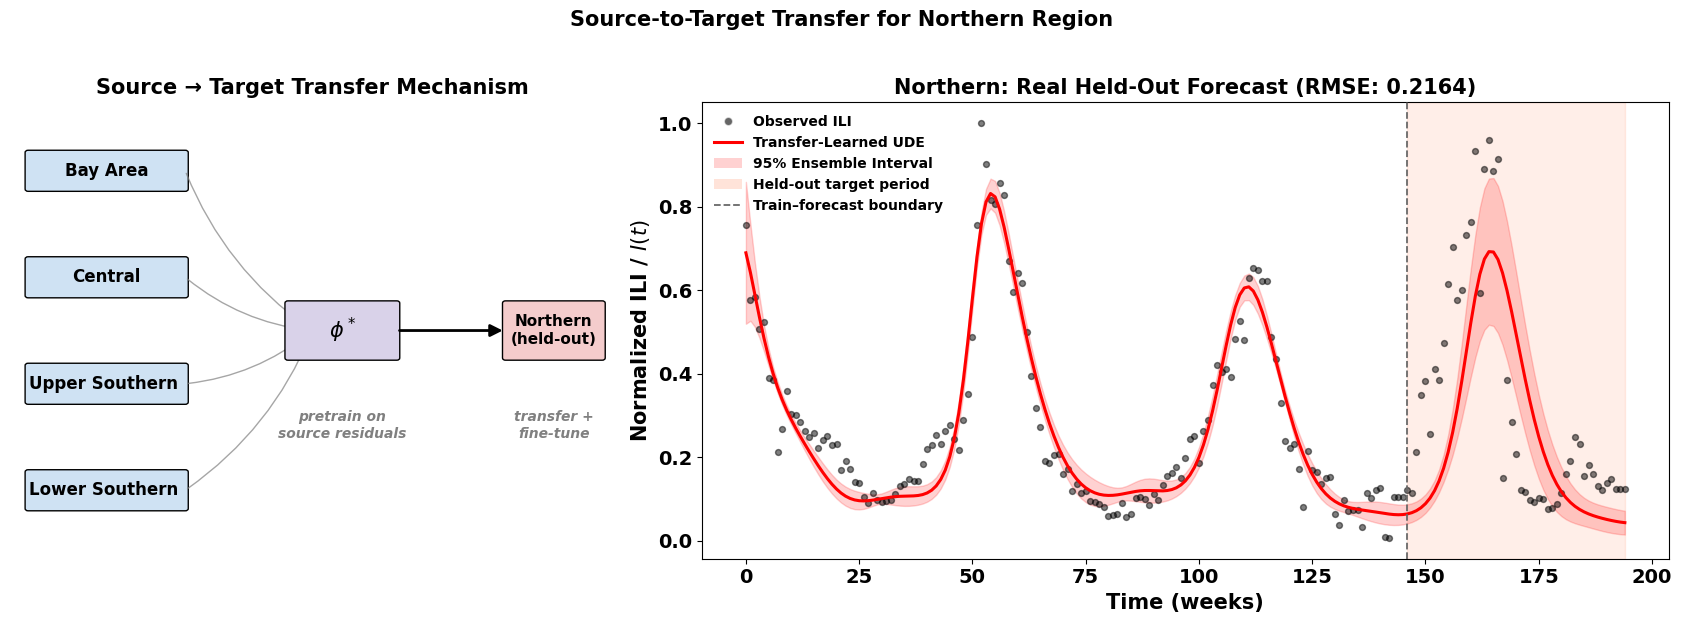

NOTE: Panel (b) uses real observed data and the same trained ensemble as Northern's panel in Figure 3 (Block 21). The region shown here is a presentation choice for pairing with the mechanism schematic in Panel (a); all five regions have equally real, independently evaluated results.


In [ ]:
# --------------------------------------------------
# BLOCK 24 (FINAL) : FIGURE — Source→Target Transfer Mechanism
# Panel (a): schematic of the transfer process (pretrain -> transfer -> fine-tune)
# Panel (b): worked example using REAL held-out forecast data for one region.
# This panel uses the SAME underlying data and computation as its counterpart
# in Figure 3 (Block 21) -- it is not synthetic, simulated, or illustrative-only.
# The region shown is a presentation choice, not a data limitation.
# --------------------------------------------------

import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D

WORKED_EXAMPLE_REGION = "Northern"
source_regions_for_example = [n for n in region_names if n != WORKED_EXAMPLE_REGION]

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1, 1.6]})

# ---- Panel (a): schematic ----
ax_a.set_xlim(0, 10)
ax_a.set_ylim(0, 10)
ax_a.axis("off")
ax_a.set_title("Source → Target Transfer Mechanism", fontsize=15, fontweight="bold")

src_y_positions = np.linspace(8.5, 1.5, len(source_regions_for_example))
for name, y in zip(source_regions_for_example, src_y_positions):
    box = mpatches.FancyBboxPatch((0.3, y-0.4), 2.6, 0.8, boxstyle="round,pad=0.05",
                                   facecolor="#cfe2f3", edgecolor="black")
    ax_a.add_patch(box)
    ax_a.text(1.6, y, name, ha="center", va="center", fontsize=12, fontweight="bold")
    ax_a.add_patch(FancyArrowPatch((2.9, y), (5.0, 5.0), connectionstyle="arc3,rad=0.15",
                                    arrowstyle="-|>", mutation_scale=14, color="gray", alpha=0.7))

phi_box = mpatches.FancyBboxPatch((4.6, 4.4), 1.8, 1.2, boxstyle="round,pad=0.05",
                                   facecolor="#d9d2e9", edgecolor="black")
ax_a.add_patch(phi_box)
ax_a.text(5.5, 5.0, r"$\phi^*$", ha="center", va="center", fontsize=15, fontweight="bold")

ax_a.add_patch(FancyArrowPatch((6.4, 5.0), (8.2, 5.0), arrowstyle="-|>",
                                mutation_scale=18, color="black", linewidth=2))
target_box = mpatches.FancyBboxPatch((8.2, 4.4), 1.6, 1.2, boxstyle="round,pad=0.05",
                                      facecolor="#f4cccc", edgecolor="black")
ax_a.add_patch(target_box)
ax_a.text(9.0, 5.0, f"{WORKED_EXAMPLE_REGION}\n(held-out)", ha="center", va="center",
          fontsize=11, fontweight="bold")

ax_a.text(5.5, 3.25, "pretrain on\nsource residuals", ha="center", va="top", fontsize=10, style="italic", color="gray", fontweight="bold")

ax_a.text(9.0, 3.25, "transfer +\nfine-tune", ha="center", va="top", fontsize=10, style="italic", color="gray", fontweight="bold")

# ---- Panel (b): the worked example region's ACTUAL held-out forecast ----
d = main_predictions[WORKED_EXAMPLE_REGION]
t_arr = d["t"]
split_week = d["split_week"]
ci_lo_clipped = np.maximum(d["ci_lo"], 0.0)

#ax_b.axvspan(t_arr[0], split_week, color="gray", alpha=0.05, zorder=0)
ax_b.axvspan(split_week, t_arr[-1], color="orangered", alpha=0.09, zorder=0)
ax_b.scatter(t_arr, d["obs"], color="black", s=18, alpha=0.5, zorder=3)
ax_b.plot(t_arr, d["pred_mean"], "r-", linewidth=2.2, zorder=4)
ax_b.fill_between(t_arr, ci_lo_clipped, d["ci_hi"], color="red", alpha=0.18, zorder=2)
ax_b.axvline(split_week, color="dimgray", linestyle="--", linewidth=1.3, zorder=5)

rmse_example = main_results_df.loc[main_results_df["Region"] == WORKED_EXAMPLE_REGION, "RMSE"].values[0]
ax_b.set_title(f"{WORKED_EXAMPLE_REGION}: Real Held-Out Forecast (RMSE: {rmse_example:.4f})",
               fontsize=15, fontweight="bold")

ax_b.set_xlabel("Time (weeks)", fontsize=15, fontweight="bold")
ax_b.set_ylabel(r"Normalized ILI / $I(t)$", fontsize=15, fontweight="bold")
plt.setp(ax_b.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_b.get_yticklabels(), fontweight="bold", fontsize=14)

# --- FIX: "95% CI" -> "95% Ensemble Interval", matching every other figure ---
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", alpha=0.6,
           markersize=6, label="Observed ILI"),
    Line2D([0], [0], color="red", linewidth=2.2, label="Transfer-Learned UDE"),
    Patch(facecolor="red", alpha=0.18, label="95% Ensemble Interval"),
    Patch(facecolor="orangered", alpha=0.15, label="Held-out target period"),
    Line2D([0], [0], color="dimgray", linestyle="--", linewidth=1.3, label="Train–forecast boundary"),
]
ax_b.legend(handles=legend_elements, fontsize=14, loc="upper left", frameon=False,
            prop={"weight": "bold"})

fig.suptitle(f"Source-to-Target Transfer for {WORKED_EXAMPLE_REGION} Region",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(f"figure3_transfer_mechanism_{WORKED_EXAMPLE_REGION}.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NOTE: Panel (b) uses real observed data and the same trained ensemble "
      f"as {WORKED_EXAMPLE_REGION}'s panel in Figure 3 (Block 21). The region shown "
      f"here is a presentation choice for pairing with the mechanism schematic in "
      f"Panel (a); all five regions have equally real, independently evaluated results.")

Block 25 — Transfer vs Random Initialization (cleaned)

  [Bay Area] Matched window check OK: n_train=146, n_test=49 (identical for both arms)
    Random RMSE=0.1844 | Transfer RMSE=0.1654
  [Central] Matched window check OK: n_train=124, n_test=42 (identical for both arms)
    Random RMSE=0.2417 | Transfer RMSE=0.3123
  [Northern] Matched window check OK: n_train=146, n_test=49 (identical for both arms)
    Random RMSE=0.2295 | Transfer RMSE=0.2164
  [Upper Southern ] Matched window check OK: n_train=132, n_test=44 (identical for both arms)
    Random RMSE=0.1920 | Transfer RMSE=0.2048
  [Lower Southern ] Matched window check OK: n_train=146, n_test=49 (identical for both arms)
    Random RMSE=0.1796 | Transfer RMSE=0.1426


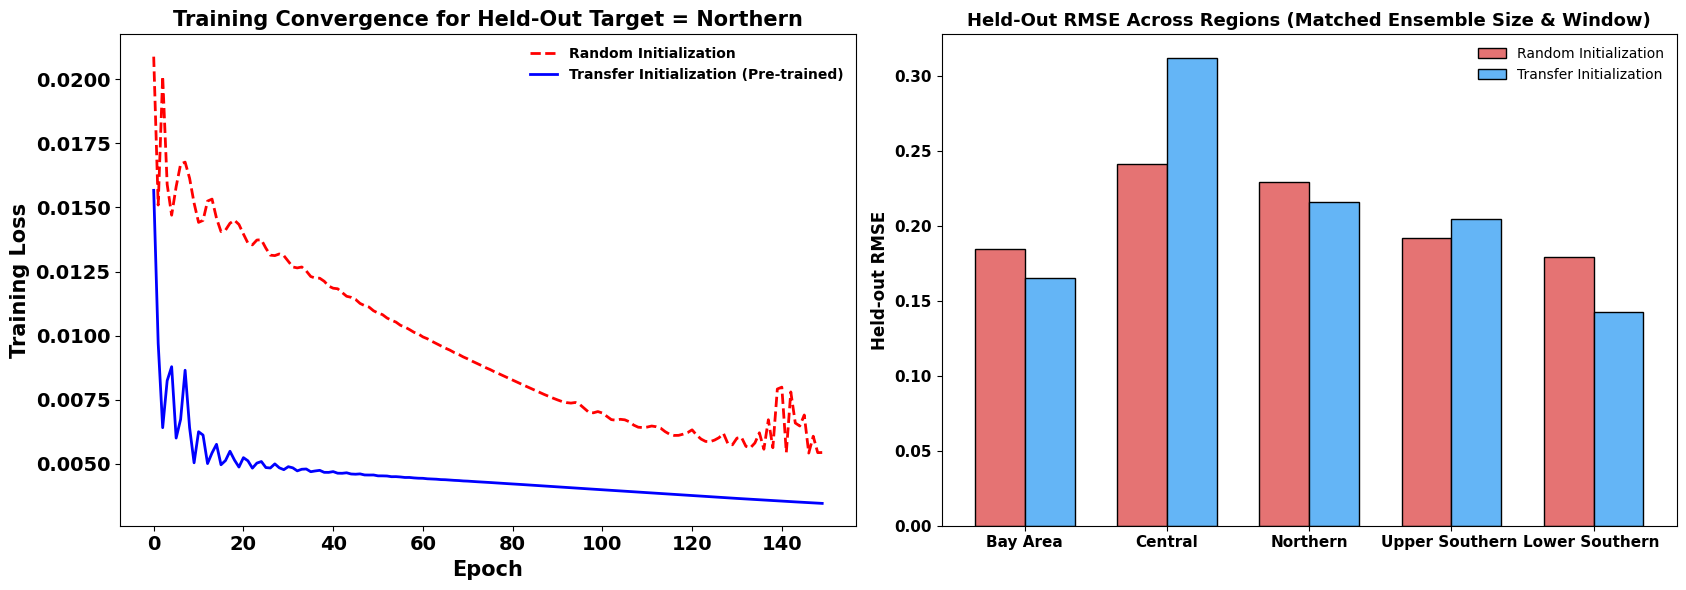


=== Table: RMSE/MAE — Random vs Transfer Initialization (matched window per region) ===


,Target,N_train,N_test,Random RMSE,Transfer RMSE,RMSE Improvement (%),Random MAE,Transfer MAE,MAE Improvement (%)
0,Bay Area,146,49,0.1844,0.1654,10.3%,0.1422,0.1283,9.7%
1,Central,124,42,0.2417,0.3123,-29.2%,0.1817,0.2250,-23.8%
2,Northern,146,49,0.2295,0.2164,5.7%,0.1918,0.1851,3.5%
3,Upper Southern,132,44,0.1920,0.2048,-6.6%,0.1423,0.1422,0.0%
4,Lower Southern,146,49,0.1796,0.1426,20.6%,0.1342,0.0975,27.3%


In [ ]:
# --------------------------------------------------
# BLOCK 25 (FINAL) : FIGURE — Transfer vs Random Initialization
# Includes explicit proof that random-init and transfer-init arms use
# IDENTICAL target-domain training/test windows within each region.
# --------------------------------------------------

d_north = main_predictions[WORKED_EXAMPLE_REGION]
t_train_n, I_train_n = d_north["t_train"], d_north["I_train"]
phi_star_state_n = d_north["phi_star_state"]

_, _, _, _, loss_hist_random = train_ude_regularized(
    t_train_n, I_train_n, params, lam_r=LAM_R, epochs=FINETUNE_EPOCHS,
    lr=3e-4, seed=42, init_state_dict=None
)
_, _, _, _, loss_hist_transfer = train_ude_regularized(
    t_train_n, I_train_n, params, lam_r=LAM_R, epochs=FINETUNE_EPOCHS,
    lr=3e-4, seed=42, init_state_dict=phi_star_state_n
)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 6))

ax_a.plot(loss_hist_random, "r--", linewidth=2, label="Random Initialization")
ax_a.plot(loss_hist_transfer, "b-", linewidth=2, label="Transfer Initialization (Pre-trained)")
ax_a.set_title(f"Training Convergence for Held-Out Target = {WORKED_EXAMPLE_REGION}",
               fontsize=15, fontweight="bold")
ax_a.set_xlabel("Epoch", fontsize=15, fontweight="bold")
ax_a.set_ylabel("Training Loss", fontsize=15, fontweight="bold")
plt.setp(ax_a.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_a.get_yticklabels(), fontweight="bold", fontsize=14)
ax_a.legend(fontsize=14, frameon=False, prop={"weight": "bold"})

N_ENSEMBLE_COMPARISON = N_ENSEMBLE   # matched to Block 20's ensemble size

comparison_rows = []

for target_name in region_names:
    d_t = main_predictions[target_name]
    t_full, I_full = d_t["t"], d_t["obs"]
    split_idx = d_t["split_idx"]
    t_train_r, I_train_r = d_t["t_train"], d_t["I_train"]

    # --------------------------------------------------
    # EXPLICIT CHECK: random-init and transfer-init arms MUST use the
    # identical target-domain training window for this region. This is
    # a hard requirement for the comparison to isolate "initialization
    # only" rather than being confounded by differing data windows.
    # --------------------------------------------------
    n_train_this_region = len(t_train_r)
    n_test_this_region = len(t_full) - split_idx
    assert n_train_this_region == split_idx, (
        f"{target_name}: t_train length ({n_train_this_region}) does not match "
        f"split_idx ({split_idx}) from Block 20 -- the two arms are NOT using "
        f"matched training windows. Do not trust this comparison until fixed."
    )
    print(f"  [{target_name}] Matched window check OK: n_train={n_train_this_region}, "
          f"n_test={n_test_this_region} (identical for both arms)")

    random_preds = []
    for seed in range(N_ENSEMBLE_COMPARISON):
        t_sub, I_sub = subsample_weeks(t_train_r, I_train_r, SUBSAMPLE_FRAC, seed)
        model_r, ode_func_r, X0_r, _, _ = train_ude_regularized(
            t_sub, I_sub, params, lam_r=LAM_R, epochs=FINETUNE_EPOCHS,
            lr=3e-4, seed=seed, init_state_dict=None
        )
        model_r.eval()
        with torch.no_grad():
            t_full_tensor = torch.tensor(t_full, dtype=torch.float32, device=device)
            pred_X = odeint(ode_func_r, X0_r, t_full_tensor, method="dopri5")
            if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
            random_preds.append(pred_X[:, 1].cpu().numpy())

    random_pred_mean = np.stack(random_preds, axis=0).mean(axis=0)

    obs_forecast = I_full[split_idx:]
    rand_forecast = random_pred_mean[split_idx:]

    rmse_rand, mae_rand, _, _ = compute_metrics_arr(obs_forecast, rand_forecast)
    rmse_trans = main_results_df.loc[main_results_df["Region"] == target_name, "RMSE"].values[0]
    mae_trans = main_results_df.loc[main_results_df["Region"] == target_name, "MAE"].values[0]

    comparison_rows.append({
        "Target": target_name,
        "N_train": n_train_this_region, "N_test": n_test_this_region,
        "Random RMSE": rmse_rand, "Transfer RMSE": rmse_trans,
        "RMSE Improvement (%)": 100*(rmse_rand - rmse_trans)/rmse_rand,
        "Random MAE": mae_rand, "Transfer MAE": mae_trans,
        "MAE Improvement (%)": 100*(mae_rand - mae_trans)/mae_rand,
    })
    print(f"    Random RMSE={rmse_rand:.4f} | Transfer RMSE={rmse_trans:.4f}")

comparison_df = pd.DataFrame(comparison_rows)

x = np.arange(len(comparison_df))
width = 0.35
ax_b.bar(x - width/2, comparison_df["Random RMSE"], width, label="Random Initialization",
         color="#e57373", edgecolor="black")
ax_b.bar(x + width/2, comparison_df["Transfer RMSE"], width, label="Transfer Initialization",
         color="#64b5f6", edgecolor="black")
ax_b.set_xticks(x)
ax_b.set_xticklabels(comparison_df["Target"], fontweight="bold")
ax_b.set_ylabel("Held-out RMSE", fontsize=12, fontweight="bold")
ax_b.set_title("Held-Out RMSE Across Regions (Matched Ensemble Size & Window)",
               fontsize=13, fontweight="bold")
plt.setp(ax_b.get_xticklabels(), fontweight="bold", fontsize=11)
plt.setp(ax_b.get_yticklabels(), fontweight="bold", fontsize=11)
ax_b.legend(fontsize=10, frameon=False)

#fig.suptitle("Effect of Transfer Initialization on Training Convergence and Forecasting\n"
             #"(within-region comparisons use matched windows; windows vary across regions)", fontsize=13.5, fontweight="bold", y=1.06)
plt.tight_layout()
plt.savefig("figure4_transfer_vs_random.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== Table: RMSE/MAE — Random vs Transfer Initialization (matched window per region) ===")
display(comparison_df.round(4).style.format({
    "Random RMSE": "{:.4f}", "Transfer RMSE": "{:.4f}", "RMSE Improvement (%)": "{:.1f}%",
    "Random MAE": "{:.4f}", "Transfer MAE": "{:.4f}", "MAE Improvement (%)": "{:.1f}%"
}).background_gradient(cmap="Greens", subset=["RMSE Improvement (%)", "MAE Improvement (%)"]))

In [ ]:
# --------------------------------------------------
# BLOCK 26 (FINAL) : Regularization Sensitivity Analysis
# Retrains the UDE from scratch at each lambda_r, computing:
#   (a) held-out forecast RMSE
#   (b) RMS magnitude of the learned transmission residual Delta_beta_phi
# NOTE: This block only computes reg_sensitivity_df. The corresponding
# figure is produced in Block 27 (Fig. 12, Panels a/b) -- no standalone
# plot is generated here, to avoid duplicating that figure.
# --------------------------------------------------

LAMBDA_R_GRID = [1e-4, 1e-3, 1e-2, 1e-1]
REG_SENSITIVITY_EPOCHS = 250
REG_SENSITIVITY_TRAIN_FRACTION = 0.75

n_total_ca = len(I_obs)
split_idx_ca = int(round(n_total_ca * REG_SENSITIVITY_TRAIN_FRACTION))
t_train_ca, I_train_ca = t_data[:split_idx_ca], I_obs[:split_idx_ca]
t_test_ca, I_test_ca = t_data[split_idx_ca:], I_obs[split_idx_ca:]

print(f"Regularization sensitivity: training on weeks 0-{t_data[split_idx_ca]:.0f} "
      f"({split_idx_ca} weeks), evaluating held-out RMSE on weeks "
      f"{t_data[split_idx_ca]:.0f}-{t_data[-1]:.0f} ({n_total_ca - split_idx_ca} weeks)\n")

reg_sensitivity_results = []

for lam_r in LAMBDA_R_GRID:
    print(f"--- lambda_r = {lam_r:.0e} ---")

    model_lr, ode_func_lr, X0_lr, t_tensor_lr, loss_hist_lr = train_ude_regularized(
        t_train_ca, I_train_ca, params, lam_r=lam_r,
        epochs=REG_SENSITIVITY_EPOCHS, lr=5e-4, seed=1234, init_state_dict=None
    )
    model_lr.eval()

    with torch.no_grad():
        t_full_tensor = torch.tensor(t_data, dtype=torch.float32, device=device)
        pred_X = odeint(ode_func_lr, X0_lr, t_full_tensor, method="dopri5")
        if pred_X.dim() == 3: pred_X = pred_X.squeeze(1)
        I_pred_full = pred_X[:, 1].cpu().numpy()

    rmse_test, mae_test, _, _ = compute_metrics_arr(I_test_ca, I_pred_full[split_idx_ca:])

    with torch.no_grad():
        residual_full = model_lr(pred_X, t_full_tensor.unsqueeze(1)).cpu().numpy().flatten()
    rms_residual = np.sqrt(np.mean(residual_full ** 2))

    reg_sensitivity_results.append({
        "lambda_r": lam_r, "Held-out RMSE": rmse_test,
        "Held-out MAE": mae_test, "RMS Residual Magnitude": rms_residual
    })
    print(f"    Held-out RMSE={rmse_test:.5f} | RMS residual magnitude={rms_residual:.5f}\n")

reg_sensitivity_df = pd.DataFrame(reg_sensitivity_results)

# --- FREEZE results to CSV (same rationale as peak_sensitivity_df in Block 27) ---
reg_sensitivity_df.to_csv("reg_sensitivity_results_frozen.csv", index=False)
print("Frozen results saved to reg_sensitivity_results_frozen.csv")

print("\n=== Table: Regularization Sensitivity ===")
display(reg_sensitivity_df.style.format({
    "lambda_r": "{:.0e}", "Held-out RMSE": "{:.5f}",
    "Held-out MAE": "{:.5f}", "RMS Residual Magnitude": "{:.5f}"
}))

Regularization sensitivity: training on weeks 0-146 (146 weeks), evaluating held-out RMSE on weeks 146-194 (49 weeks)

--- lambda_r = 1e-04 ---
    Held-out RMSE=0.22747 | RMS residual magnitude=0.34057

--- lambda_r = 1e-03 ---
    Held-out RMSE=0.23204 | RMS residual magnitude=0.32858

--- lambda_r = 1e-02 ---
    Held-out RMSE=0.22947 | RMS residual magnitude=0.31211

--- lambda_r = 1e-01 ---
    Held-out RMSE=0.24222 | RMS residual magnitude=0.16711

Frozen results saved to reg_sensitivity_results_frozen.csv

=== Table: Regularization Sensitivity ===


,lambda_r,Held-out RMSE,Held-out MAE,RMS Residual Magnitude
0,1e-04,0.22747,0.15409,0.34057
1,1e-03,0.23204,0.15900,0.32858
2,1e-02,0.22947,0.15742,0.31211
3,1e-01,0.24222,0.16710,0.16711


First-wave (weeks 0-52) peak sensitivity computed:
  scale=0.000: peak=0.7059 at week 2
  scale=0.143: peak=0.6844 at week 2
  scale=0.286: peak=0.6593 at week 2
  scale=0.429: peak=0.6828 at week 52
  scale=0.571: peak=0.7313 at week 52
  scale=0.714: peak=0.7746 at week 52
  scale=0.857: peak=0.8100 at week 52
  scale=1.000: peak=0.8252 at week 52
  scale=1.143: peak=0.7780 at week 52
  scale=1.286: peak=0.6589 at week 52
  scale=1.429: peak=0.6022 at week 34
  scale=1.571: peak=0.6429 at week 52
  scale=1.714: peak=0.6773 at week 52
  scale=1.857: peak=0.6601 at week 52
  scale=2.000: peak=0.6262 at week 52

Frozen results saved to peak_sensitivity_results_frozen.csv


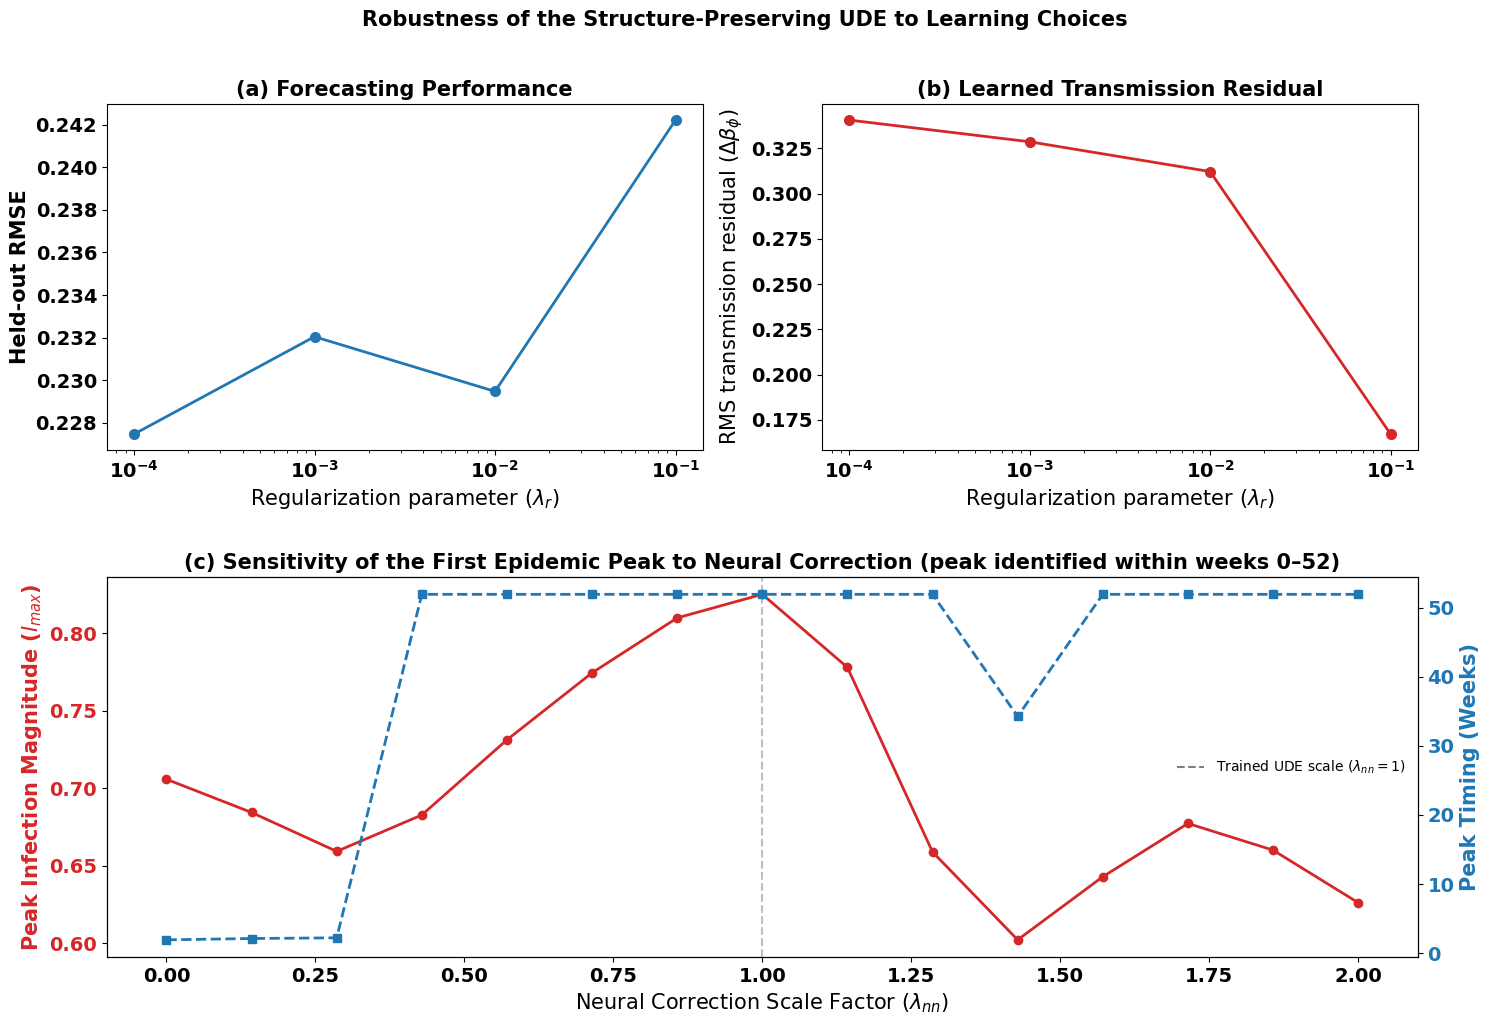

In [ ]:
TARGET_WAVE = 1

seasonal_residual_nn.eval()
nn_scales = np.linspace(0.0, 2.0, 15)
peak_magnitudes_fw = []
peak_weeks_fw = []

wave_start = (TARGET_WAVE - 1) * 52
wave_end = TARGET_WAVE * 52
wave_mask = (t_fine >= wave_start) & (t_fine < wave_end)

with torch.no_grad():
    for scale in nn_scales:
        scaled_func = ScaledODEFunc(seasonal_residual_nn, params, scale).to(device)
        pred = odeint(scaled_func, X0, t_fine_tensor, method="dopri5")
        if pred.dim() == 3: pred = pred.squeeze(1)
        I_traj = pred[:, 1].cpu().numpy()

        I_wave = I_traj[wave_mask]
        t_wave = t_fine[wave_mask]
        peak_idx = np.argmax(I_wave)

        peak_magnitudes_fw.append(I_wave[peak_idx])
        peak_weeks_fw.append(t_wave[peak_idx])

print(f"First-wave (weeks {wave_start:.0f}-{wave_end:.0f}) peak sensitivity computed:")
for s, m, w in zip(nn_scales, peak_magnitudes_fw, peak_weeks_fw):
    print(f"  scale={s:.3f}: peak={m:.4f} at week {w:.0f}")

# --- FREEZE results to CSV ---
peak_sensitivity_df = pd.DataFrame({
    "lambda_nn": nn_scales,
    "peak_magnitude": peak_magnitudes_fw,
    "peak_timing_weeks": peak_weeks_fw,
})
peak_sensitivity_df.to_csv("peak_sensitivity_results_frozen.csv", index=False)
print("\nFrozen results saved to peak_sensitivity_results_frozen.csv")

# --- Assemble combined 3-panel figure ---
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c1 = fig.add_subplot(gs[1, :])
ax_c2 = ax_c1.twinx()

# Panel (a)
ax_a.plot(reg_sensitivity_df["lambda_r"], reg_sensitivity_df["Held-out RMSE"],
          "o-", color="#1f77b4", linewidth=2, markersize=7)
ax_a.set_xscale("log")
ax_a.set_xlabel(r"$\text{Regularization parameter (}\lambda_r\text{)}$", fontsize=15, fontweight="bold")
ax_a.set_ylabel("Held-out RMSE", fontsize=15, fontweight="bold")
ax_a.set_title("(a) Forecasting Performance", fontsize=15, fontweight="bold", loc="center")
plt.setp(ax_a.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_a.get_yticklabels(), fontweight="bold", fontsize=14)

# Panel (b)
ax_b.plot(reg_sensitivity_df["lambda_r"], reg_sensitivity_df["RMS Residual Magnitude"],
          "o-", color="#d62728", linewidth=2, markersize=7)
ax_b.set_xscale("log")
ax_b.set_xlabel(r"$\text{Regularization parameter (}\lambda_r\text{)}$", fontsize=15, fontweight="bold")
ax_b.set_ylabel(r"$\text{RMS transmission residual (}\Delta\beta_\phi\text{)}$", fontsize=15, fontweight="bold")
ax_b.set_title("(b) Learned Transmission Residual", fontsize=15, fontweight="bold", loc="center")
plt.setp(ax_b.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_b.get_yticklabels(), fontweight="bold", fontsize=14)

# Panel (c)
color1 = "tab:red"
ax_c1.plot(peak_sensitivity_df["lambda_nn"], peak_sensitivity_df["peak_magnitude"],
           color=color1, linewidth=2, marker="o")
ax_c1.set_xlabel(r"$\text{Neural Correction Scale Factor (}\lambda_{nn}\text{)}$", fontsize=15, fontweight="bold")
ax_c1.set_ylabel(r"Peak Infection Magnitude ($I_{max}$)", color=color1, fontsize=15, fontweight="bold")
ax_c1.tick_params(axis="y", labelcolor=color1, labelsize=14)
ax_c1.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
plt.setp(ax_c1.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_c1.get_yticklabels(), fontweight="bold")

color2 = "tab:blue"
ax_c2.plot(peak_sensitivity_df["lambda_nn"], peak_sensitivity_df["peak_timing_weeks"],
           color=color2, linewidth=2, linestyle="--", marker="s")
ax_c2.set_ylabel("Peak Timing (Weeks)", color=color2, fontsize=15, fontweight="bold")
ax_c2.tick_params(axis="y", labelcolor=color2, labelsize=14)
plt.setp(ax_c2.get_yticklabels(), fontweight="bold")

# FIX: removed stray ")", added explicit wave-range disclosure
ax_c1.set_title(
    r"(c) Sensitivity of the First Epidemic Peak to Neural Correction"
    f" (peak identified within weeks {wave_start:.0f}\u2013{wave_end:.0f})",
    fontsize=15, fontweight="bold", loc="center"
)

legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", label=r"$\text{Trained UDE scale (}\lambda_{nn}=1\text{)}$")
]
# FIX: moved off-center to avoid overlapping the plotted curves
ax_c1.legend(handles=legend_elements, loc="center right", fontsize=14, frameon=False,
             prop={"weight": "bold"})

fig.suptitle("Robustness of the Structure-Preserving UDE to Learning Choices",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(h_pad=3.0)
plt.savefig("figure12_robustness_combined.png", dpi=300, bbox_inches="tight")
plt.show()

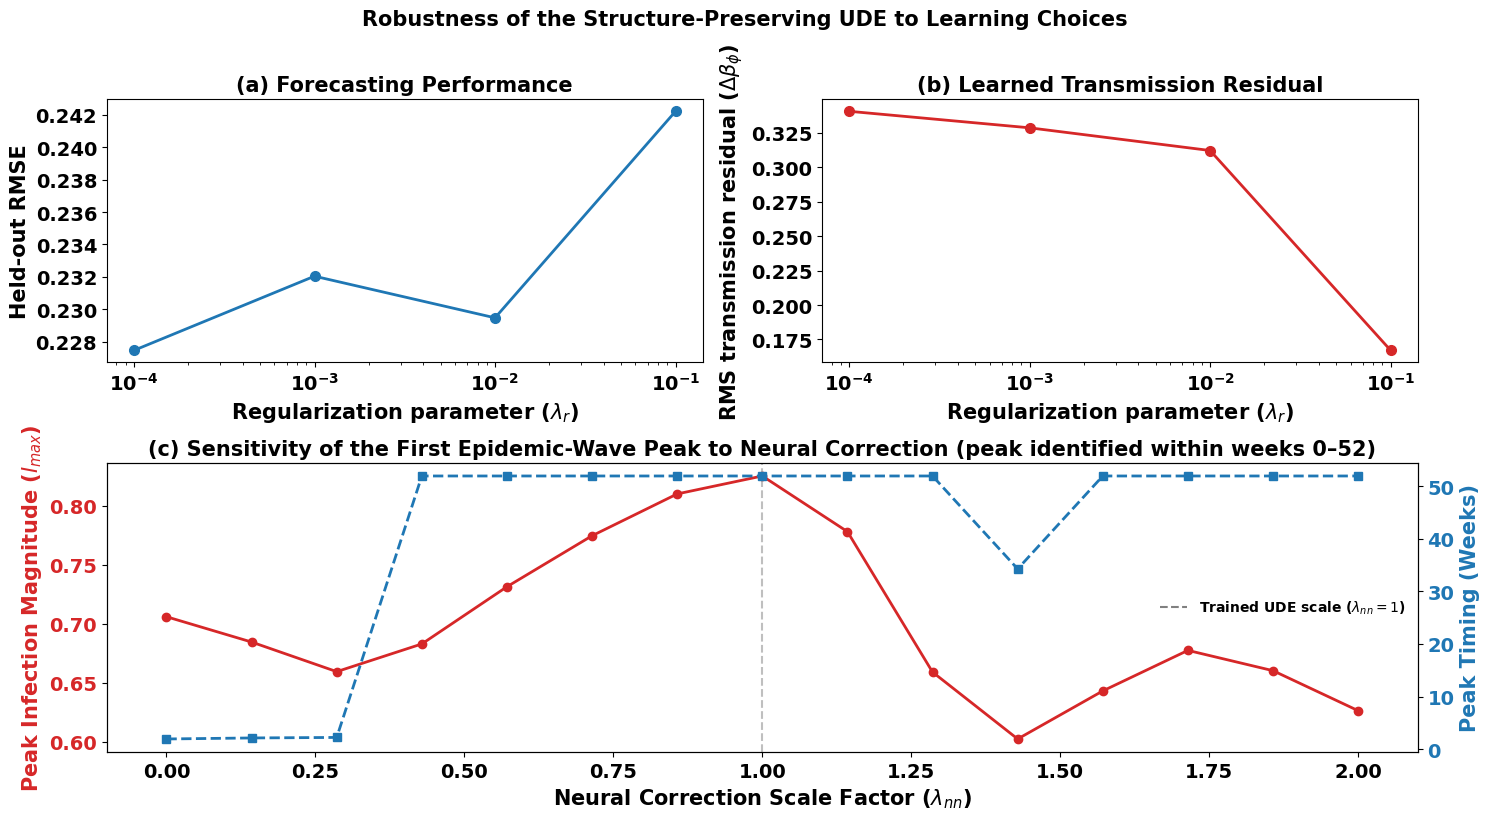

In [ ]:
# --------------------------------------------------
# BLOCK 27 (FINAL, BOLD LABELS) : Fig. 12 — Combined Robustness Figure
# --------------------------------------------------

TARGET_WAVE = 1

seasonal_residual_nn.eval()
nn_scales = np.linspace(0.0, 2.0, 15)
peak_magnitudes_fw = []
peak_weeks_fw = []

wave_start = (TARGET_WAVE - 1) * 52
wave_end = TARGET_WAVE * 52
wave_mask = (t_fine >= wave_start) & (t_fine < wave_end)

with torch.no_grad():
    for scale in nn_scales:
        scaled_func = ScaledODEFunc(seasonal_residual_nn, params, scale).to(device)
        pred = odeint(scaled_func, X0, t_fine_tensor, method="dopri5")
        if pred.dim() == 3: pred = pred.squeeze(1)
        I_traj = pred[:, 1].cpu().numpy()

        I_wave = I_traj[wave_mask]
        t_wave = t_fine[wave_mask]
        peak_idx = np.argmax(I_wave)

        peak_magnitudes_fw.append(I_wave[peak_idx])
        peak_weeks_fw.append(t_wave[peak_idx])

peak_sensitivity_df = pd.DataFrame({
    "lambda_nn": nn_scales,
    "peak_magnitude": peak_magnitudes_fw,
    "peak_timing_weeks": peak_weeks_fw,
})
peak_sensitivity_df.to_csv("peak_sensitivity_results_frozen.csv", index=False)

# --- Assemble combined 3-panel figure ---
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c1 = fig.add_subplot(gs[1, :])
ax_c2 = ax_c1.twinx()

# Panel (a)
ax_a.plot(reg_sensitivity_df["lambda_r"], reg_sensitivity_df["Held-out RMSE"],
          "o-", color="#1f77b4", linewidth=2, markersize=7)
ax_a.set_xscale("log")
ax_a.set_xlabel(r"Regularization parameter ($\lambda_r$)", fontsize=15, fontweight="bold")
ax_a.set_ylabel("Held-out RMSE", fontsize=15, fontweight="bold")
ax_a.set_title("(a) Forecasting Performance", fontsize=15, fontweight="bold", loc="center")
plt.setp(ax_a.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_a.get_yticklabels(), fontweight="bold", fontsize=14)

# Panel (b)
ax_b.plot(reg_sensitivity_df["lambda_r"], reg_sensitivity_df["RMS Residual Magnitude"],
          "o-", color="#d62728", linewidth=2, markersize=7)
ax_b.set_xscale("log")
ax_b.set_xlabel(r"Regularization parameter ($\lambda_r$)", fontsize=15, fontweight="bold")
ax_b.set_ylabel(r"RMS transmission residual ($\Delta\beta_\phi$)", fontsize=15, fontweight="bold")
ax_b.set_title("(b) Learned Transmission Residual", fontsize=15, fontweight="bold", loc="center")
plt.setp(ax_b.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_b.get_yticklabels(), fontweight="bold", fontsize=14)

# Panel (c)
color1 = "tab:red"
ax_c1.plot(peak_sensitivity_df["lambda_nn"], peak_sensitivity_df["peak_magnitude"],
           color=color1, linewidth=2, marker="o")
ax_c1.set_xlabel(r"Neural Correction Scale Factor ($\lambda_{nn}$)", fontsize=15, fontweight="bold")
ax_c1.set_ylabel(r"Peak Infection Magnitude ($I_{max}$)", color=color1, fontsize=15, fontweight="bold")
ax_c1.tick_params(axis="y", labelcolor=color1, labelsize=14)
ax_c1.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
plt.setp(ax_c1.get_xticklabels(), fontweight="bold", fontsize=14)
plt.setp(ax_c1.get_yticklabels(), fontweight="bold")

color2 = "tab:blue"
ax_c2.plot(peak_sensitivity_df["lambda_nn"], peak_sensitivity_df["peak_timing_weeks"],
           color=color2, linewidth=2, linestyle="--", marker="s")
ax_c2.set_ylabel("Peak Timing (Weeks)", color=color2, fontsize=15, fontweight="bold")
ax_c2.tick_params(axis="y", labelcolor=color2, labelsize=14)
plt.setp(ax_c2.get_yticklabels(), fontweight="bold")

# --- FIX: explicitly force bold on every axis label object, including
# the twin axis (ax_c2), since set_ylabel's fontweight kwarg can be
# silently overridden by later rcParams/style calls in some environments ---
for ax in [ax_a, ax_b, ax_c1, ax_c2]:
    ax.xaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_fontsize(15)
    ax.yaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontsize(15)

ax_c1.set_title(
    r"(c) Sensitivity of the First Epidemic-Wave Peak to Neural Correction "
    f"(peak identified within weeks {wave_start:.0f}\u2013{wave_end:.0f})",
    fontsize=15, fontweight="bold", loc="center"
)

legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", label=r"Trained UDE scale ($\lambda_{nn}=1$)")
]
ax_c1.legend(handles=legend_elements, loc="center right", fontsize=14, frameon=False,
             prop={"weight": "bold"})

fig.suptitle("Robustness of the Structure-Preserving UDE to Learning Choices",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure12_robustness_combined.png", dpi=300, bbox_inches="tight")
plt.show()